Using device: cuda
Starting MMPDE iterative training for Sine-Gordon

【Phase 1】Initial training with uniform sampling (3000 epochs)
Generated uniform collocation grid: 21×19×19 = 7581 points
Time range: [0.000, 10.000]
Starting initial Adam training...
Adam Epoch [500/3000], Loss: 4.623239e-02
Adam Epoch [1000/3000], Loss: 1.129043e-02
Adam Epoch [1500/3000], Loss: 6.058497e-03
Adam Epoch [2000/3000], Loss: 3.369354e-03
Adam Epoch [2500/3000], Loss: 2.307339e-03
Adam Epoch [3000/3000], Loss: 1.637060e-03
Starting initial LBFGS training...
LBFGS Step [200/1000], Loss: 2.023447e-05
LBFGS Step [400/1000], Loss: 6.493868e-06
LBFGS Step [600/1000], Loss: 2.956119e-06
LBFGS Step [800/1000], Loss: 1.636943e-06
LBFGS Step [1000/1000], Loss: 9.477408e-07
Initial training completed

【Phase 2】MMPDE adaptive sampling + continue training
Performing MMPDE adaptive sampling...
Generated MMPDE initial sampling grid: 21×19×19 = 7581 points
Time range for MMPDE: [0.000, 10.000]
Starting 2D MMPDE trainin

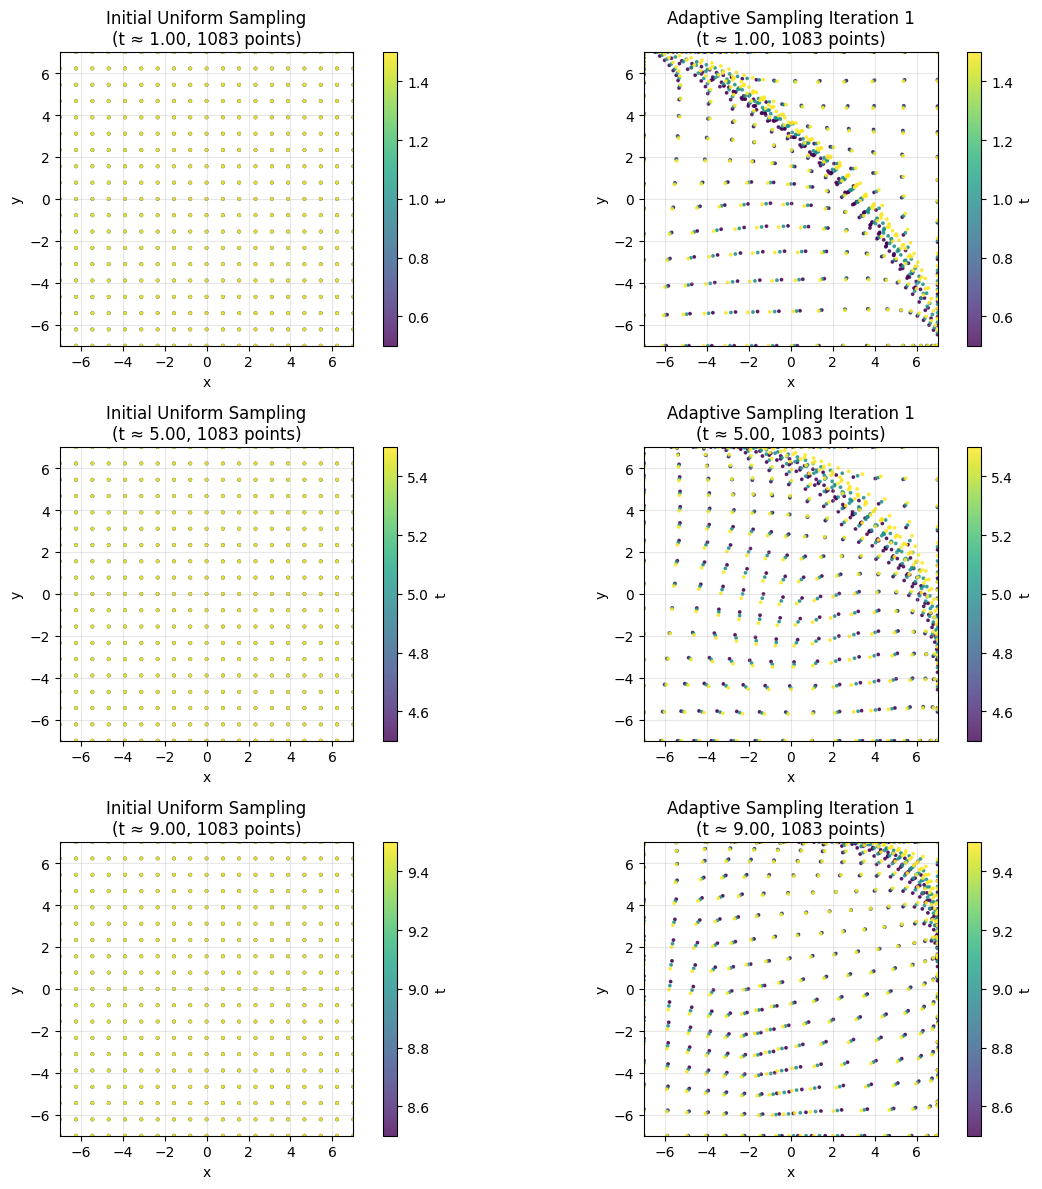

Training completed!
MMPDE-PINN训练完成，损失历史已保存到 mmpde_loss_history.npy

Evaluating model accuracy...
u - MSE: 7.289840e-07, Max Error: 4.731178e-03
v - MSE: 9.311543e-07, Max Error: 6.112695e-03


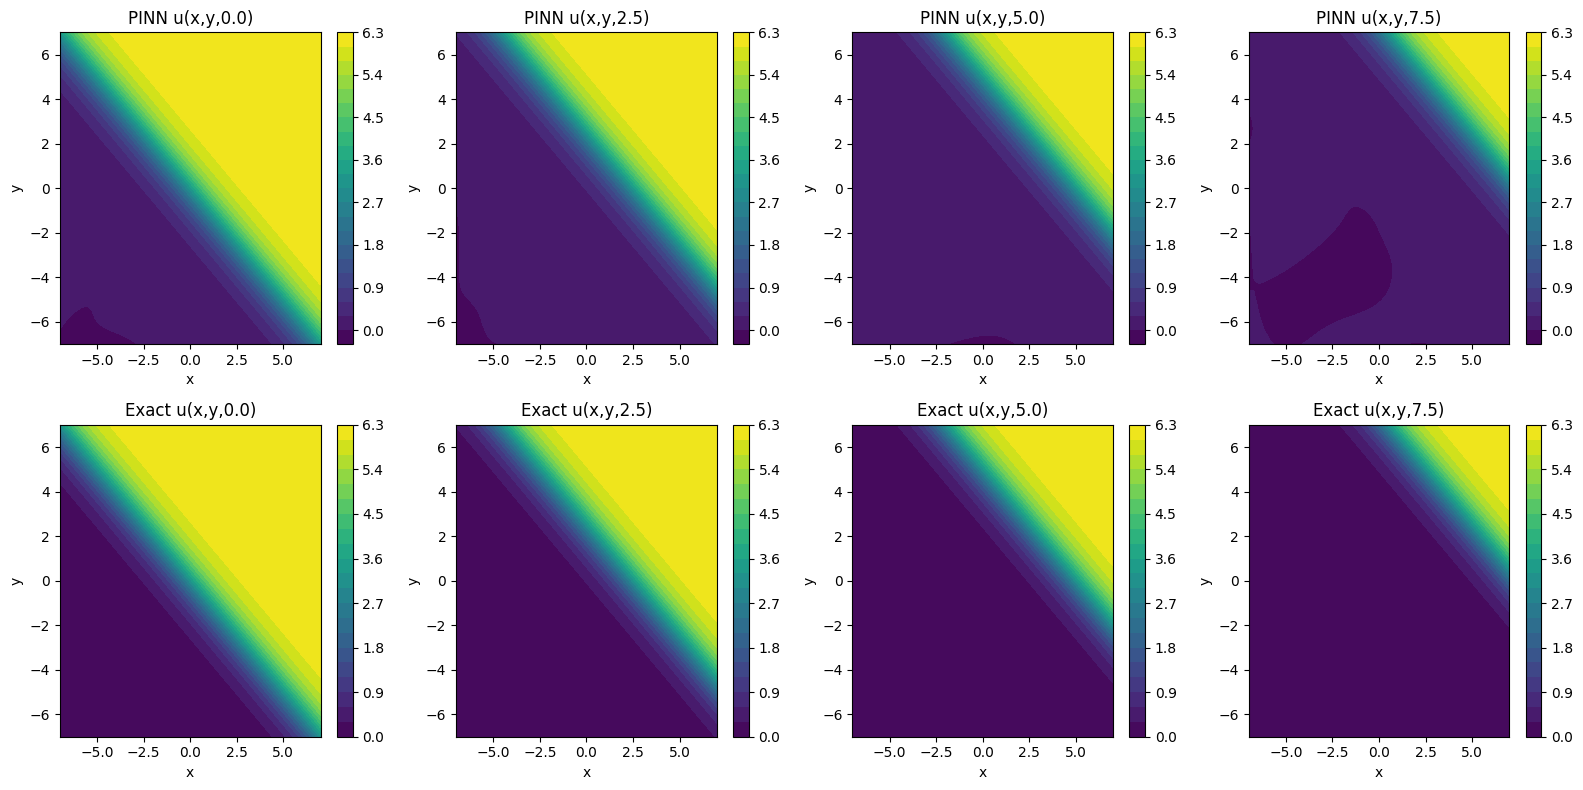


Final Results:
u displacement - MSE: 7.289840e-07
v velocity - MSE: 9.311543e-07
Maximum errors - u: 4.731178e-03, v: 6.112695e-03


In [2]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import OrderedDict

################################################################################
# PINN for the 2D Sine-Gordon Equation (First-order System Form)
#
# PDE System:
#   du/dt = v
#   dv/dt = u_xx + u_yy - sin(u)
# Domain:
#   t in [0, T], x in [-7, 7], y in [-7, 7]
# Initial Conditions:
#   u(x, y, 0)  = 4*arctan(exp(x + y))
#   v(x, y, 0)  = -4*exp(x + y) / (1 + exp(2*x + 2*y))
# Boundary Conditions:
#   u(t, ±7, y) = 4*arctan(exp(±7 + y - t))
#   u(t, x, ±7) = 4*arctan(exp(x ± 7 - t))
# Analytical Solution:
#   u(x, y, t) = 4*arctan(exp(x + y - t))
################################################################################

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

################################################################################
# Hyperparameters / Problem Setup
################################################################################
Lx_min, Lx_max = -7.0, 7.0    # Spatial domain: x in [-7, 7]
Ly_min, Ly_max = -7.0, 7.0    # Spatial domain: y in [-7, 7]
T = 10.0                       # Temporal domain: t in [0, T] - 设置为10

n_collocation = 8000          # Number of collocation points inside domain
n_boundary    = 400           # Number of points for boundary conditions (each boundary)
n_initial     = 1600          # Number of points for initial conditions
hidden_layers = 6             # Number of hidden layers
neurons       = 64            # Neurons per hidden layer
learning_rate = 1e-3          # Learning rate for optimizer

################################################################################
# Analytical Solutions and Initial/Boundary Conditions
################################################################################
def analytical_solution_u(x, y, t):
    """Analytical solution: u(x,y,t) = 4*arctan(exp(x + y - t))"""
    return 4 * np.arctan(np.exp(x + y - t))

def analytical_solution_v(x, y, t):
    """Analytical solution for v = du/dt"""
    exp_term = np.exp(x + y - t)
    return -4 * exp_term / (1 + exp_term**2)

def initial_condition_u(x, y):
    """Initial condition for u: u(x,y,0) = 4*arctan(exp(x + y))"""
    return 4 * np.arctan(np.exp(x + y))

def initial_condition_v(x, y):
    """Initial condition for v: v(x,y,0) = -4*exp(x + y)/(1 + exp(2*x + 2*y))"""
    return -4 * np.exp(x + y) / (1 + np.exp(2*x + 2*y))

def boundary_condition_u(x, y, t):
    """Boundary condition for u using analytical solution"""
    return analytical_solution_u(x, y, t)

def boundary_condition_v(x, y, t):
    """Boundary condition for v using analytical solution"""
    return analytical_solution_v(x, y, t)

################################################################################
# 2D MMPDE Sampling Class for 2D Sine-Gordon Equation
################################################################################
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()
        self.depth = len(layers) - 1
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class sampling_MMPDE_2D():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)

        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.y_f = torch.tensor(X_f[:, 2:3], requires_grad=True).float().to(device)
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        self.dnn = DNN(layers).to(device)

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, t, x, y):
        """
        Monitor function for Sine-Gordon equation:
        Based on u_x² + u_y² + u_t² + 2(1 - cos(u))
        """
        t.requires_grad_(True)
        x.requires_grad_(True) 
        y.requires_grad_(True)
        
        inputs = torch.cat([t, x, y], dim=1)
        uv = self.fun(inputs)
        u = uv[:, [0]]  # displacement u
        v = uv[:, [1]]  # velocity v = u_t

        # Compute spatial gradients of u
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]
        
        u_y = torch.autograd.grad(
            u, y,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]

        # Handle potential None gradients
        if u_x is None:
            u_x = torch.zeros_like(u)
        if u_y is None:
            u_y = torch.zeros_like(u)

        # Monitor function for Sine-Gordon: sqrt(u_x² + u_y² + v² + 2(1 - cos(u)))
        w = torch.sqrt(u_x**2 + u_y**2 + v**2 + 2*(1 - torch.cos(u)) + 1e-8)
        
        return w

    def net_sample(self, t, x, y):
        """Generate new sampling points - adaptive adjustment for x and y coordinates"""
        inputs = torch.cat([t, x, y], dim=1)
        xy_new = self.dnn(inputs)
        
        x_new = xy_new[:, [0]]
        y_new = xy_new[:, [1]]
        
        # Apply boundary constraints
        gx0 = x - self.lb[1]  # x - x_min
        gx1 = x - self.ub[1]  # x - x_max
        gy0 = y - self.lb[2]  # y - y_min  
        gy1 = y - self.ub[2]  # y - y_max
        
        # Ensure new coordinates equal original coordinates at boundaries
        x_new = gx0 * gx1 * x_new + x
        y_new = gy0 * gy1 * y_new + y
        
        return x_new, y_new

    def net_f(self, t, x, y):
        """Calculate residual of 2D MMPDE equations"""
        x_new, y_new = self.net_sample(t, x, y)

        # Time derivatives of new coordinates
        x_new_t = torch.autograd.grad(
            x_new, t,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_t = torch.autograd.grad(
            y_new, t,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        # Spatial derivatives of new coordinates
        x_new_x = torch.autograd.grad(
            x_new, x,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_y = torch.autograd.grad(
            x_new, y,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_x = torch.autograd.grad(
            y_new, x,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_y = torch.autograd.grad(
            y_new, y,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        # Second-order derivatives of new coordinates
        x_new_xx = torch.autograd.grad(
            x_new_x, x,
            grad_outputs=torch.ones_like(x_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_yy = torch.autograd.grad(
            x_new_y, y,
            grad_outputs=torch.ones_like(x_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_xx = torch.autograd.grad(
            y_new_x, x,
            grad_outputs=torch.ones_like(y_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_yy = torch.autograd.grad(
            y_new_y, y,
            grad_outputs=torch.ones_like(y_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        G = self.monitor(t, x, y)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_y = torch.autograd.grad(
            G, y,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # 2D MMPDE equation residuals
        E_x = G_x * x_new_x + G_y * x_new_y + G * (x_new_xx + x_new_yy)
        f_x = x_new_t * self.nu * (G**2) * (x_new_x**2 + x_new_y**2) + E_x

        E_y = G_x * y_new_x + G_y * y_new_y + G * (y_new_xx + y_new_yy)
        f_y = y_new_t * self.nu * (G**2) * (y_new_x**2 + y_new_y**2) + E_y

        return f_x, f_y

    def loss_func(self):
        """Calculate loss function"""
        f_x, f_y = self.net_f(self.t_f, self.x_f, self.y_f)
        loss_f = torch.mean(f_x ** 2) + torch.mean(f_y ** 2)
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = '2D_MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = '2D_MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        """Training process"""
        print("Starting 2D MMPDE training for Sine-Gordon...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("2D MMPDE_Adam completed!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('2D MMPDE_LBFGS completed!')

        # Return new sampling points
        x_new, y_new = self.net_sample(self.t_f, self.x_f, self.y_f)
        new_sample = torch.cat([self.t_f, x_new, y_new], dim=1)
        return new_sample

################################################################################
# Neural Network Definition
################################################################################
class PINN(nn.Module):
    def __init__(self, layers, activation=nn.Tanh()):
        super(PINN, self).__init__()
        
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        
        self.activation = activation
        
        # Initialize weights (Xavier initialization)
        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # Forward pass
        for i in range(len(self.linears) - 1):
            x = self.activation(self.linears[i](x))
        # output: [u, v] where v = u_t
        x = self.linears[-1](x)
        return x

################################################################################
# Physics-Informed Loss Function (First-order System Form for Sine-Gordon)
################################################################################
def sine_gordon_pde_loss(model, t, x, y):
    """
    Compute PDE residual for the first-order Sine-Gordon system:
    du/dt = v
    dv/dt = u_xx + u_yy - sin(u)
    """
    # 确保输入张量需要梯度
    if not t.requires_grad:
        t = t.clone().detach().requires_grad_(True)
    if not x.requires_grad:
        x = x.clone().detach().requires_grad_(True)
    if not y.requires_grad:
        y = y.clone().detach().requires_grad_(True)

    # NN output: [u, v]
    inputs = torch.cat((t, x, y), dim=1)
    uv = model(inputs)
    u = uv[:, [0]] 
    v = uv[:, [1]]  

    # First derivatives of u
    u_grads = torch.autograd.grad(u, inputs, 
                                 grad_outputs=torch.ones_like(u), 
                                 create_graph=True)[0]
    u_t = u_grads[:, [0]]
    u_x = u_grads[:, [1]]
    u_y = u_grads[:, [2]]

    # First derivatives of v
    v_grads = torch.autograd.grad(v, inputs,
                                 grad_outputs=torch.ones_like(v),
                                 create_graph=True)[0]
    v_t = v_grads[:, [0]]

    # Second spatial derivatives of u
    u_xx = torch.autograd.grad(u_x, x,
                              grad_outputs=torch.ones_like(u_x),
                              create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y,
                              grad_outputs=torch.ones_like(u_y),
                              create_graph=True)[0]

    # PDE residuals for the first-order Sine-Gordon system:
    # Equation 1: du/dt = v
    f_u = u_t - v
    
    # Equation 2: dv/dt = u_xx + u_yy - sin(u)
    f_v = v_t - (u_xx + u_yy - torch.sin(u))

    return torch.mean(f_u**2) + torch.mean(f_v**2)

def initial_condition_loss(model, t, x, y, uv_true):
    """Compute loss for initial conditions"""
    inputs = torch.cat((t, x, y), dim=1)
    uv_pred = model(inputs)
    ic_loss = torch.mean((uv_pred - uv_true)**2)
    return ic_loss

def boundary_condition_loss(model, boundary_pts):
    """Compute loss for boundary conditions"""
    bc_loss = 0
    
    for boundary_name, (t, x, y, uv_true) in boundary_pts.items():
        inputs = torch.cat((t, x, y), dim=1)
        uv_pred = model(inputs)
        bc_loss += torch.mean((uv_pred - uv_true)**2)
    
    return bc_loss

def loss_function(model, collocation_pts, initial_pts, boundary_pts):
    """Compute total loss for the PINN"""
    # Unpack data
    t_coll, x_coll, y_coll = collocation_pts
    t_init, x_init, y_init, uv_init = initial_pts
    
    # PDE residual loss
    pde_loss = sine_gordon_pde_loss(model, t_coll, x_coll, y_coll)
    
    # Initial condition loss
    ic_loss = initial_condition_loss(model, t_init, x_init, y_init, uv_init)
    
    # Boundary condition loss
    bc_loss = boundary_condition_loss(model, boundary_pts)
    
    # Combine losses with appropriate weights
    total_loss = pde_loss + 10*ic_loss + 10*bc_loss
    
    # 记录MMPDE-PINN损失历史
    if not hasattr(loss_function, 'mmpde_loss_history'):
        loss_function.mmpde_loss_history = []
    loss_function.mmpde_loss_history.append(total_loss.item())
    
    return total_loss, pde_loss, ic_loss, bc_loss

# 添加一个简单的损失计算函数用于LBFGS中的损失打印
def simple_loss_calculation(model, collocation_pts, initial_pts, boundary_pts):
    """
    简单的损失计算，用于LBFGS训练中的损失打印，不需要梯度
    """
    model.eval()
    with torch.no_grad():
        # 获取模型输出
        t_coll, x_coll, y_coll = collocation_pts
        t_init, x_init, y_init, uv_init = initial_pts
        
        # 计算PDE损失（简化版，不计算梯度）
        inputs_coll = torch.cat((t_coll, x_coll, y_coll), dim=1)
        uv_coll = model(inputs_coll)
        
        # 初始条件损失
        inputs_init = torch.cat((t_init, x_init, y_init), dim=1)
        uv_init_pred = model(inputs_init)
        ic_loss = torch.mean((uv_init_pred - uv_init)**2)
        
        # 边界条件损失
        bc_loss = 0
        for boundary_name, (t, x, y, uv_true) in boundary_pts.items():
            inputs = torch.cat((t, x, y), dim=1)
            uv_pred = model(inputs)
            bc_loss += torch.mean((uv_pred - uv_true)**2)
        
        # 总损失的近似值
        total_loss = ic_loss + bc_loss
        
    model.train()
    return total_loss

################################################################################
# Iterative Training Strategy: PINN + MMPDE Alternating Optimization
################################################################################
def create_2d_simulation_function_from_model(model):
    """Create simulation function based on current PINN model"""
    def simulation_function(txy):
        model.eval()
        txy = txy.to(device)
        if not txy.requires_grad:
            txy.requires_grad_(True)
        return model(txy)
    return simulation_function

def generate_uniform_collocation_points(n_points=n_collocation):
    """Generate uniformly distributed collocation points"""
    # 修正：确保在时间维度有足够的分布
    n_t = max(int(np.power(n_points, 1/3)) + 2, 12)  # 增加时间点数
    n_xy = max(int(np.sqrt(n_points / n_t)), 8)  # 空间维度的点数
    
    # 确保实际生成的点数接近目标
    while n_t * n_xy * n_xy < n_points * 0.8:  # 至少达到目标的80%
        if n_xy < n_t:
            n_xy += 1
        else:
            n_t += 1
    
    t_uniform = torch.linspace(0, T, n_t, device=device)
    x_uniform = torch.linspace(Lx_min, Lx_max, n_xy, device=device)  
    y_uniform = torch.linspace(Ly_min, Ly_max, n_xy, device=device)
    
    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')
    
    t_coll = T_grid.reshape(-1, 1)
    x_coll = X_grid.reshape(-1, 1)
    y_coll = Y_grid.reshape(-1, 1)
    
    t_coll.requires_grad_(True)
    x_coll.requires_grad_(True)
    y_coll.requires_grad_(True)
    
    print(f"Generated uniform collocation grid: {n_t}×{n_xy}×{n_xy} = {t_coll.shape[0]} points")
    print(f"Time range: [{t_coll.min().item():.3f}, {t_coll.max().item():.3f}]")
    
    return (t_coll, x_coll, y_coll)

def generate_initial_training_data():
    """Generate initial training data (uniform sampling)"""
    # Uniform collocation points
    collocation_pts = generate_uniform_collocation_points()
    
    # Initial condition points
    grid_size = int(np.sqrt(n_initial))
    x_init_grid, y_init_grid = np.meshgrid(
        np.linspace(Lx_min, Lx_max, grid_size), 
        np.linspace(Ly_min, Ly_max, grid_size)
    )
    x_init = x_init_grid.flatten().reshape(-1, 1)
    y_init = y_init_grid.flatten().reshape(-1, 1)
    t_init = np.zeros_like(x_init)
    
    # Initial conditions using the specified functions
    u_init = initial_condition_u(x_init, y_init)
    v_init = initial_condition_v(x_init, y_init)
    uv_init = np.column_stack((u_init.flatten(), v_init.flatten()))
    
    t_init = torch.tensor(t_init, dtype=torch.float32, device=device, requires_grad=True)
    x_init = torch.tensor(x_init, dtype=torch.float32, device=device, requires_grad=True)
    y_init = torch.tensor(y_init, dtype=torch.float32, device=device, requires_grad=True)
    uv_init = torch.tensor(uv_init, dtype=torch.float32, device=device)
    
    # Boundary condition points - 修正时间范围
    t_bound_values = torch.rand(n_boundary, 1, device=device) * T  # 使用T而不是固定值
    
    # Left boundary (x = -7)
    t_bound_left = t_bound_values.clone()
    x_bound_left = Lx_min * torch.ones(n_boundary, 1, device=device)
    y_bound_left = torch.rand(n_boundary, 1, device=device) * (Ly_max - Ly_min) + Ly_min
    
    # Right boundary (x = 7)
    t_bound_right = t_bound_values.clone()
    x_bound_right = Lx_max * torch.ones(n_boundary, 1, device=device)
    y_bound_right = torch.rand(n_boundary, 1, device=device) * (Ly_max - Ly_min) + Ly_min
    
    # Bottom boundary (y = -7)
    t_bound_bottom = t_bound_values.clone()
    x_bound_bottom = torch.rand(n_boundary, 1, device=device) * (Lx_max - Lx_min) + Lx_min
    y_bound_bottom = Ly_min * torch.ones(n_boundary, 1, device=device)
    
    # Top boundary (y = 7)
    t_bound_top = t_bound_values.clone()
    x_bound_top = torch.rand(n_boundary, 1, device=device) * (Lx_max - Lx_min) + Lx_min
    y_bound_top = Ly_max * torch.ones(n_boundary, 1, device=device)
    
    # Calculate boundary condition values using analytical solution
    u_bound_left = boundary_condition_u(x_bound_left.cpu().numpy(), y_bound_left.cpu().numpy(), t_bound_left.cpu().numpy())
    v_bound_left = boundary_condition_v(x_bound_left.cpu().numpy(), y_bound_left.cpu().numpy(), t_bound_left.cpu().numpy())
    uv_bound_left = torch.tensor(np.column_stack((u_bound_left.flatten(), v_bound_left.flatten())), dtype=torch.float32, device=device)
    
    u_bound_right = boundary_condition_u(x_bound_right.cpu().numpy(), y_bound_right.cpu().numpy(), t_bound_right.cpu().numpy())
    v_bound_right = boundary_condition_v(x_bound_right.cpu().numpy(), y_bound_right.cpu().numpy(), t_bound_right.cpu().numpy())
    uv_bound_right = torch.tensor(np.column_stack((u_bound_right.flatten(), v_bound_right.flatten())), dtype=torch.float32, device=device)
    
    u_bound_bottom = boundary_condition_u(x_bound_bottom.cpu().numpy(), y_bound_bottom.cpu().numpy(), t_bound_bottom.cpu().numpy())
    v_bound_bottom = boundary_condition_v(x_bound_bottom.cpu().numpy(), y_bound_bottom.cpu().numpy(), t_bound_bottom.cpu().numpy())
    uv_bound_bottom = torch.tensor(np.column_stack((u_bound_bottom.flatten(), v_bound_bottom.flatten())), dtype=torch.float32, device=device)
    
    u_bound_top = boundary_condition_u(x_bound_top.cpu().numpy(), y_bound_top.cpu().numpy(), t_bound_top.cpu().numpy())
    v_bound_top = boundary_condition_v(x_bound_top.cpu().numpy(), y_bound_top.cpu().numpy(), t_bound_top.cpu().numpy())
    uv_bound_top = torch.tensor(np.column_stack((u_bound_top.flatten(), v_bound_top.flatten())), dtype=torch.float32, device=device)
    
    # Set gradients for boundary tensors
    for tensor in [t_bound_left, x_bound_left, y_bound_left,
                  t_bound_right, x_bound_right, y_bound_right,
                  t_bound_bottom, x_bound_bottom, y_bound_bottom,
                  t_bound_top, x_bound_top, y_bound_top]:
        tensor.requires_grad_(True)
    
    initial_pts = (t_init, x_init, y_init, uv_init)
    boundary_pts = {
        'left': (t_bound_left, x_bound_left, y_bound_left, uv_bound_left),
        'right': (t_bound_right, x_bound_right, y_bound_right, uv_bound_right),
        'bottom': (t_bound_bottom, x_bound_bottom, y_bound_bottom, uv_bound_bottom),
        'top': (t_bound_top, x_bound_top, y_bound_top, uv_bound_top)
    }
    
    return collocation_pts, initial_pts, boundary_pts

def generate_initial_samples_2d(n_samples=5000):
    """Generate initial sampling points for 2D domain"""
    # 修正：确保时间维度有合适的分布
    n_t = max(int(np.power(n_samples, 1/3)) + 2, 12)  # 增加时间点数
    n_xy = max(int(np.sqrt(n_samples / n_t)), 8)
    
    # 确保实际生成的点数接近目标
    while n_t * n_xy * n_xy < n_samples * 0.8:
        if n_xy < n_t:
            n_xy += 1
        else:
            n_t += 1
    
    t_uniform = torch.linspace(0, T, n_t)
    x_uniform = torch.linspace(Lx_min, Lx_max, n_xy)  
    y_uniform = torch.linspace(Ly_min, Ly_max, n_xy)
    
    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')
    
    t_init = T_grid.reshape(-1, 1)
    x_init = X_grid.reshape(-1, 1)
    y_init = Y_grid.reshape(-1, 1)
    
    X_f_init = torch.cat([t_init, x_init, y_init], dim=1).numpy()
    
    print(f"Generated MMPDE initial sampling grid: {n_t}×{n_xy}×{n_xy} = {X_f_init.shape[0]} points")
    print(f"Time range for MMPDE: [{X_f_init[:, 0].min():.3f}, {X_f_init[:, 0].max():.3f}]")
    
    return X_f_init

def iterative_training_with_adaptive_sampling(
    initial_epochs=3000,      # 第一次3000次Adam
    adaptive_epochs=3000,     # 第二次3000次Adam  
    num_iterations=1,         # 只做1次迭代（总共2次训练）
    mmpde_training_epochs=500 # MMPDE训练保持不变
):
    """
    修改后的迭代训练策略：
    1. 初始训练：3000次Adam + 1000次LBFGS
    2. 一次MMPDE自适应采样
    3. 继续训练：3000次Adam + 1000次LBFGS
    """
    
    print("=" * 80)
    print("Starting MMPDE iterative training for Sine-Gordon")
    print("=" * 80)
    
    # 初始化损失历史
    loss_function.mmpde_loss_history = []
    
    # ==================== Phase 1: Initial Training ====================
    print(f"\n【Phase 1】Initial training with uniform sampling ({initial_epochs} epochs)")
    
    # Create initial model
    layers = [3] + [neurons]*hidden_layers + [2]
    model = PINN(layers, activation=nn.Tanh()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    lbfgs_optimizer = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=1)
    
    # Initial training data
    collocation_pts, initial_pts, boundary_pts = generate_initial_training_data()
    
    # 存储采样点历史
    sampling_points_history = []
    t_coll, x_coll, y_coll = collocation_pts
    initial_samples = torch.cat([t_coll, x_coll, y_coll], dim=1).detach().cpu().numpy()
    sampling_points_history.append(("Initial Uniform Sampling", initial_samples))
    
    # 第一阶段训练：3000次Adam + 1000次LBFGS
    print("Starting initial Adam training...")
    for epoch in range(initial_epochs):
        optimizer.zero_grad()
        loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 500 == 0:
            print(f"Adam Epoch [{epoch+1}/{initial_epochs}], Loss: {loss.item():.6e}")
    
    print("Starting initial LBFGS training...")
    # 手动控制LBFGS 1000次
    def closure():
        optimizer.zero_grad()
        loss, _, _, _ = loss_function(model, collocation_pts, initial_pts, boundary_pts)
        loss.backward()
        return loss
    
    for lbfgs_step in range(1000):
        lbfgs_optimizer.step(closure)
        if (lbfgs_step + 1) % 200 == 0:
            # 使用简化的损失计算进行打印
            simple_loss = simple_loss_calculation(model, collocation_pts, initial_pts, boundary_pts)
            print(f"LBFGS Step [{lbfgs_step+1}/1000], Loss: {simple_loss.item():.6e}")
    
    print(f"Initial training completed")
    
    # ==================== Phase 2: MMPDE + Continue Training ====================
    print(f"\n【Phase 2】MMPDE adaptive sampling + continue training")
    
    # MMPDE采样
    print("Performing MMPDE adaptive sampling...")
    X_f_init = generate_initial_samples_2d(n_samples=n_collocation)
    current_sim_func = create_2d_simulation_function_from_model(model)
    
    mmpde_layers_2d = [3, 50, 50, 50, 2]
    adam_iter = mmpde_training_epochs // 2
    lbfgs_iter = mmpde_training_epochs // 4
    
    mmpde_sampler = sampling_MMPDE_2D(
        X_f=X_f_init,
        u_fun=current_sim_func,
        layers=mmpde_layers_2d,
        lb=[0.0, Lx_min, Ly_min],
        ub=[T, Lx_max, Ly_max],
        nu=0.1,
        AdamIter=adam_iter,
        LBFGSIter=lbfgs_iter
    )
    
    new_samples = mmpde_sampler.train()
    new_samples_np = new_samples.detach().cpu().numpy()
    sampling_points_history.append(("Adaptive Sampling Iteration 1", new_samples_np))
    
    # 更新采样点
    t_colloc_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
    x_colloc_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
    y_colloc_new = new_samples[:, 2:3].clone().detach().requires_grad_(True)
    collocation_pts = (t_colloc_new, x_colloc_new, y_colloc_new)
    
    # 第二阶段训练：3000次Adam + 1000次LBFGS
    print(f"Continue training with new sampling points...")
    
    print("Starting adaptive Adam training...")
    for epoch in range(adaptive_epochs):
        optimizer.zero_grad()
        loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 500 == 0:
            print(f"Adam Epoch [{epoch+1}/{adaptive_epochs}], Loss: {loss.item():.6e}")
    
    print("Starting adaptive LBFGS training...")
    # 手动控制LBFGS 1000次
    for lbfgs_step in range(1000):
        lbfgs_optimizer.step(closure)
        if (lbfgs_step + 1) % 200 == 0:
            # 使用简化的损失计算进行打印
            simple_loss = simple_loss_calculation(model, collocation_pts, initial_pts, boundary_pts)
            print(f"LBFGS Step [{lbfgs_step+1}/1000], Loss: {simple_loss.item():.6e}")
    
    print("Training completed!")
    
    # 保存损失历史
    np.save('mmpde_loss_history.npy', np.array(loss_function.mmpde_loss_history))
    
    # 可视化采样演化
    print("\nGenerating sampling point visualization...")
    visualize_sampling_evolution(sampling_points_history)
    
    return model, {
        'loss_history': loss_function.mmpde_loss_history,
        'sampling_points_history': sampling_points_history
    }

def visualize_sampling_evolution(sampling_points_history, n_display_points=2000):
    """
    Visualize the evolution of sampling points
    
    Parameters:
    -----------
    sampling_points_history : list
        List containing (description, sampling_points_array) pairs
    n_display_points : int
        Number of points to display (randomly sampled to avoid overcrowding)
    """
    n_plots = len(sampling_points_history)
    
    # Create subplots
    fig = plt.figure(figsize=(6*n_plots, 12))
    
    # 首先检查数据的时间范围并调整时间切片
    print("Checking time ranges in sampling data...")
    for title, points in sampling_points_history:
        t_min, t_max = points[:, 0].min(), points[:, 0].max()
        print(f"{title}: t_range = [{t_min:.3f}, {t_max:.3f}], n_points = {len(points)}")
    
    # 基于实际数据范围选择时间切片
    all_t_values = []
    for _, points in sampling_points_history:
        all_t_values.extend(points[:, 0])
    
    t_min_global = min(all_t_values)
    t_max_global = max(all_t_values)
    
    # 选择三个具有代表性的时间切片
    time_slices = [
        t_min_global + 0.1 * (t_max_global - t_min_global),
        t_min_global + 0.5 * (t_max_global - t_min_global), 
        t_min_global + 0.9 * (t_max_global - t_min_global)
    ]
    
    print(f"Selected time slices: {[f'{t:.3f}' for t in time_slices]}")
    
    for time_idx, t_slice in enumerate(time_slices):
        for plot_idx, (title, points) in enumerate(sampling_points_history):
            # Select points close to specified time - 增大时间容忍度
            t_coords = points[:, 0]
            time_tolerance = max(0.5, (t_max_global - t_min_global) * 0.1)  # 动态调整容忍度
            time_mask = np.abs(t_coords - t_slice) < time_tolerance
            
            print(f"Time slice {t_slice:.3f}, {title}: {np.sum(time_mask)} points within tolerance {time_tolerance:.3f}")
            
            if np.sum(time_mask) > 5:  # 降低最小点数要求
                filtered_points = points[time_mask]
                
                # Random sampling to avoid overcrowding
                if len(filtered_points) > n_display_points:
                    indices = np.random.choice(len(filtered_points), n_display_points, replace=False)
                    display_points = filtered_points[indices]
                else:
                    display_points = filtered_points
                
                # Create subplot
                ax = fig.add_subplot(len(time_slices), n_plots, time_idx*n_plots + plot_idx + 1)
                
                # Scatter plot
                scatter = ax.scatter(display_points[:, 1], display_points[:, 2], 
                                   c=display_points[:, 0], cmap='viridis', 
                                   s=3, alpha=0.8)
                
                ax.set_xlim(Lx_min, Lx_max)
                ax.set_ylim(Ly_min, Ly_max)
                ax.set_xlabel('x')
                ax.set_ylabel('y')
                ax.set_title(f'{title}\n(t ≈ {t_slice:.2f}, {len(display_points)} points)')
                ax.grid(True, alpha=0.3)
                ax.set_aspect('equal')
                
                # Add colorbar
                plt.colorbar(scatter, ax=ax, label='t')
            else:
                # 如果点数不足，显示整个时间域的投影
                ax = fig.add_subplot(len(time_slices), n_plots, time_idx*n_plots + plot_idx + 1)
                
                # 显示所有点但用透明度区分
                if len(points) > n_display_points:
                    indices = np.random.choice(len(points), n_display_points, replace=False)
                    display_points = points[indices]
                else:
                    display_points = points
                
                scatter = ax.scatter(display_points[:, 1], display_points[:, 2], 
                                   c=display_points[:, 0], cmap='viridis', 
                                   s=1, alpha=0.3)
                
                ax.set_xlim(Lx_min, Lx_max)
                ax.set_ylim(Ly_min, Ly_max)
                ax.set_xlabel('x')
                ax.set_ylabel('y')
                ax.set_title(f'{title}\n(All times - insufficient data at t≈{t_slice:.2f})')
                ax.grid(True, alpha=0.3)
                ax.set_aspect('equal')
                
                plt.colorbar(scatter, ax=ax, label='t')
    
    plt.tight_layout()
    plt.show()

def evaluate_model_accuracy(model, n_test_points=1000):
    """
    Evaluate model accuracy against analytical solution
    """
    print("\nEvaluating model accuracy...")
    
    # Generate test points
    t_test = torch.rand(n_test_points, 1, device=device) * T
    x_test = torch.rand(n_test_points, 1, device=device) * (Lx_max - Lx_min) + Lx_min
    y_test = torch.rand(n_test_points, 1, device=device) * (Ly_max - Ly_min) + Ly_min
    
    # Model predictions
    model.eval()
    with torch.no_grad():
        inputs_test = torch.cat([t_test, x_test, y_test], dim=1)
        uv_pred = model(inputs_test)
        u_pred = uv_pred[:, 0].cpu().numpy()
        v_pred = uv_pred[:, 1].cpu().numpy()
    
    # Analytical solutions
    t_np = t_test.cpu().numpy()
    x_np = x_test.cpu().numpy()
    y_np = y_test.cpu().numpy()
    
    u_exact = analytical_solution_u(x_np, y_np, t_np).flatten()
    v_exact = analytical_solution_v(x_np, y_np, t_np).flatten()
    
    # Calculate errors
    u_error = np.abs(u_pred - u_exact)
    v_error = np.abs(v_pred - v_exact)
    
    u_mse = np.mean(u_error**2)
    v_mse = np.mean(v_error**2)
    u_max_error = np.max(u_error)
    v_max_error = np.max(v_error)
    
    print(f"u - MSE: {u_mse:.6e}, Max Error: {u_max_error:.6e}")
    print(f"v - MSE: {v_mse:.6e}, Max Error: {v_max_error:.6e}")
    
    return {
        'u_mse': u_mse,
        'v_mse': v_mse,
        'u_max_error': u_max_error,
        'v_max_error': v_max_error
    }

def plot_training_history(training_history):
    """Plot training loss history"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Total loss
    axes[0,0].semilogy(training_history['loss_history'])
    axes[0,0].set_title('Total Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].grid(True)
    
    plt.tight_layout()
    plt.show()

def visualize_solution_comparison(model, t_values=[0, T/4, T/2, 3*T/4]):
    """
    Visualize comparison between PINN prediction and analytical solution
    """
    fig, axes = plt.subplots(2, len(t_values), figsize=(4*len(t_values), 8))
    
    # Create spatial grid
    x_grid = np.linspace(Lx_min, Lx_max, 50)
    y_grid = np.linspace(Ly_min, Ly_max, 50)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    for i, t_val in enumerate(t_values):
        # Prepare input for model
        t_flat = np.full(X.flatten().shape, t_val)
        x_flat = X.flatten()
        y_flat = Y.flatten()
        
        # PINN prediction
        model.eval()
        with torch.no_grad():
            inputs = torch.tensor(np.column_stack([t_flat, x_flat, y_flat]), 
                                dtype=torch.float32, device=device)
            uv_pred = model(inputs).cpu().numpy()
            u_pred = uv_pred[:, 0].reshape(X.shape)
        
        # Analytical solution
        u_exact = analytical_solution_u(X, Y, t_val)
        
        # Plot PINN prediction
        im1 = axes[0, i].contourf(X, Y, u_pred, levels=20, cmap='viridis')
        axes[0, i].set_title(f'PINN u(x,y,{t_val:.1f})')
        axes[0, i].set_xlabel('x')
        axes[0, i].set_ylabel('y')
        plt.colorbar(im1, ax=axes[0, i])
        
        # Plot analytical solution
        im2 = axes[1, i].contourf(X, Y, u_exact, levels=20, cmap='viridis')
        axes[1, i].set_title(f'Exact u(x,y,{t_val:.1f})')
        axes[1, i].set_xlabel('x')
        axes[1, i].set_ylabel('y')
        plt.colorbar(im2, ax=axes[1, i])
    
    plt.tight_layout()
    plt.show()

################################################################################
# 主程序执行
################################################################################
if __name__ == "__main__":
    # 运行修改后的迭代训练
    trained_model, training_history = iterative_training_with_adaptive_sampling()

    print("Training completed!")
    print("MMPDE-PINN训练完成，损失历史已保存到 mmpde_loss_history.npy")
    
    # 保存模型
    complete_save_dict = {
        'model_state_dict': trained_model.state_dict(),
        'training_history': training_history,
        'model_architecture': [3] + [64]*6 + [2],
    }
    torch.save(complete_save_dict, 'mmpde_pinn_complete.pth')
    
    # 评估和可视化
    accuracy_results = evaluate_model_accuracy(trained_model)
    visualize_solution_comparison(trained_model)
    
    print(f"\nFinal Results:")
    print(f"u displacement - MSE: {accuracy_results['u_mse']:.6e}")
    print(f"v velocity - MSE: {accuracy_results['v_mse']:.6e}")
    print(f"Maximum errors - u: {accuracy_results['u_max_error']:.6e}, v: {accuracy_results['v_max_error']:.6e}")

In [4]:
from scipy.integrate import dblquad


Using device: cuda
MMPDE-PINN 多时刻可视化 (T=10.0)
生成测试数据...
测试数据生成完成：200000 个测试点
时间范围：[0.0, 10.0]，共20个时间点
目标时间点：[0, 5.0, 10.0]
实际时间点：['0.0', '5.3', '10.0'] (索引: [0, 10, 19])
模型加载成功！

1. 绘制精确解与预测解（3个时刻 × 2张图 = 6张图）


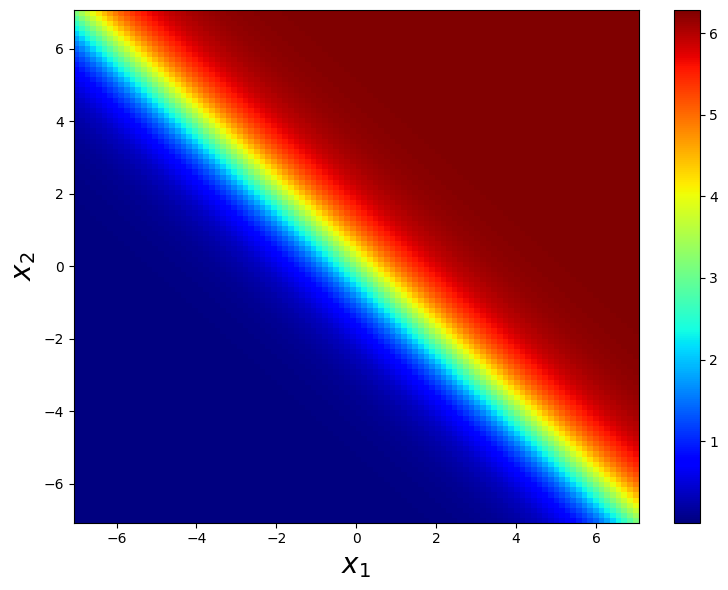

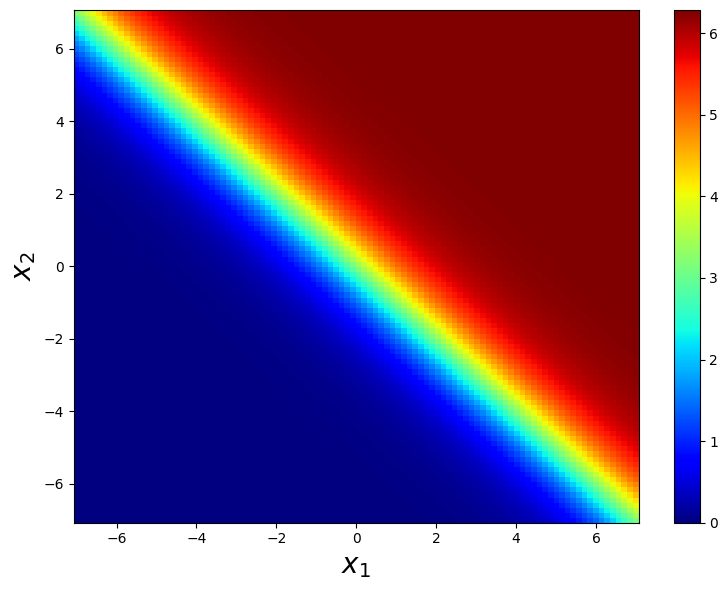

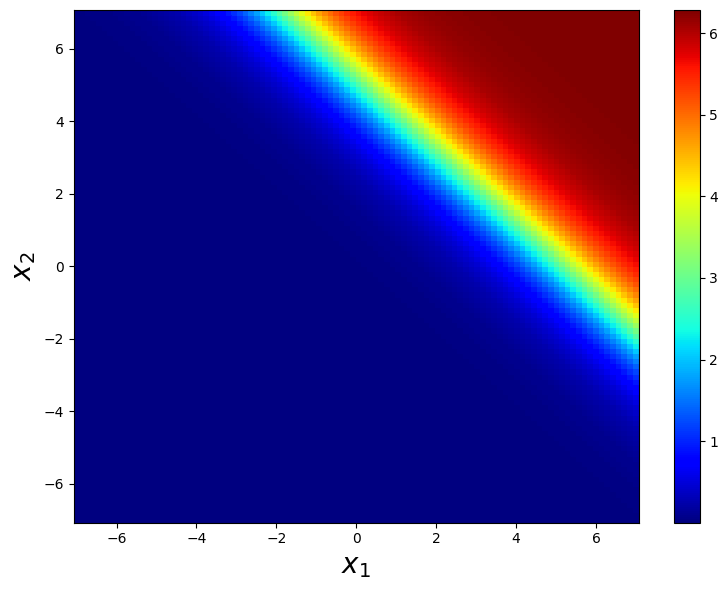

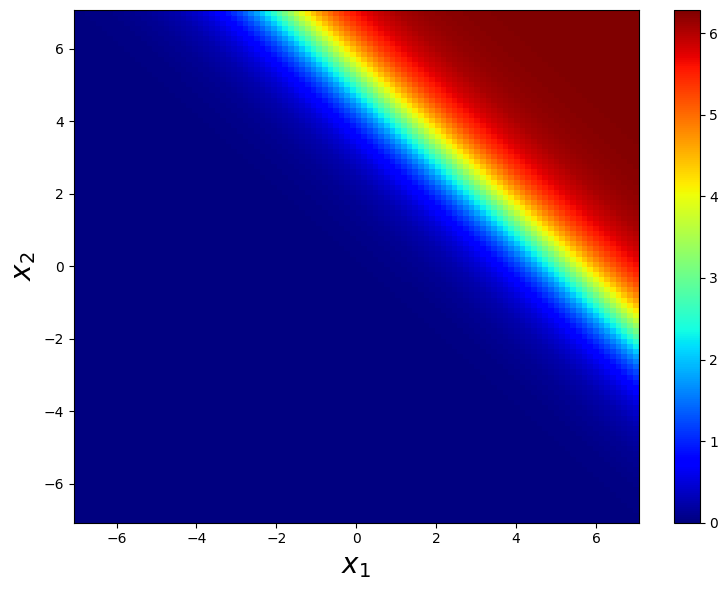

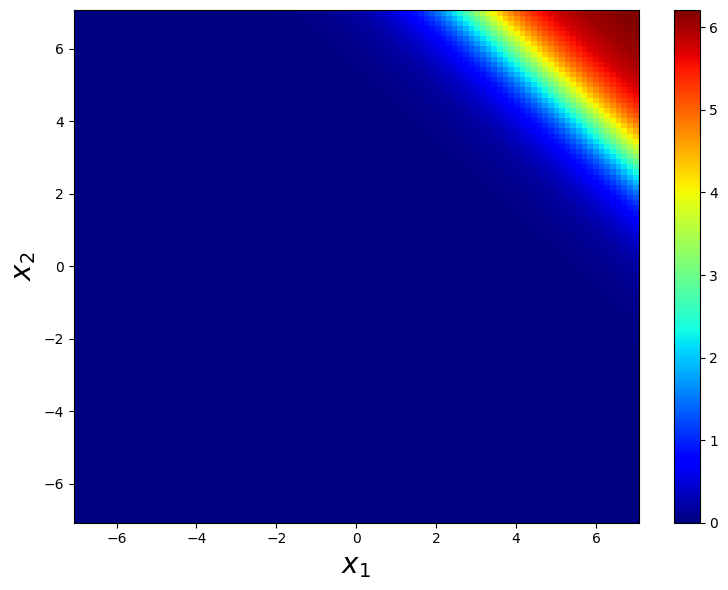

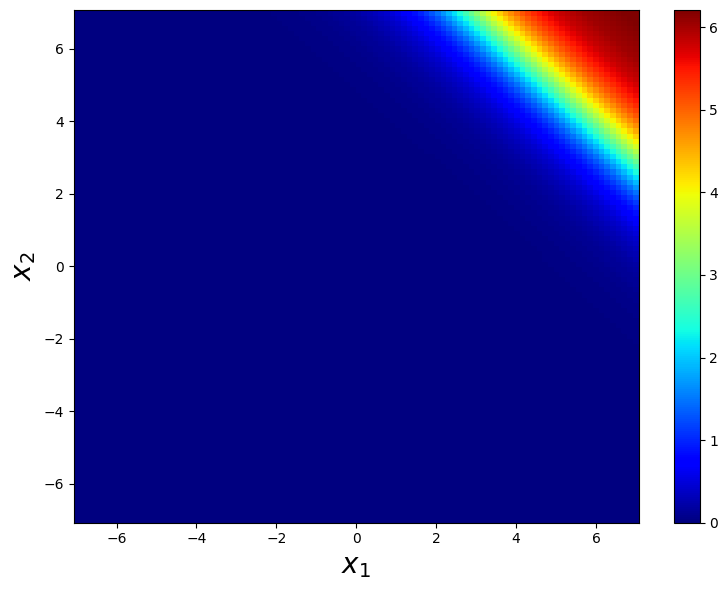


2. 绘制误差分布（3张图）


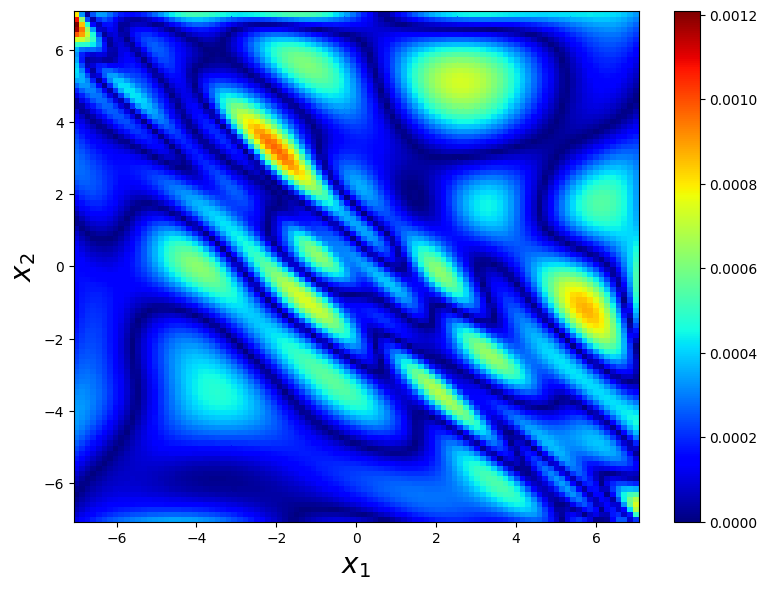

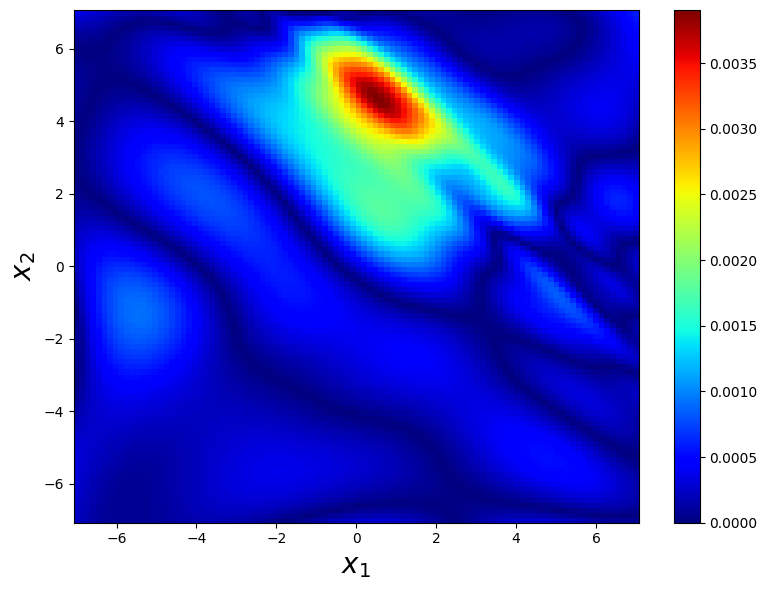

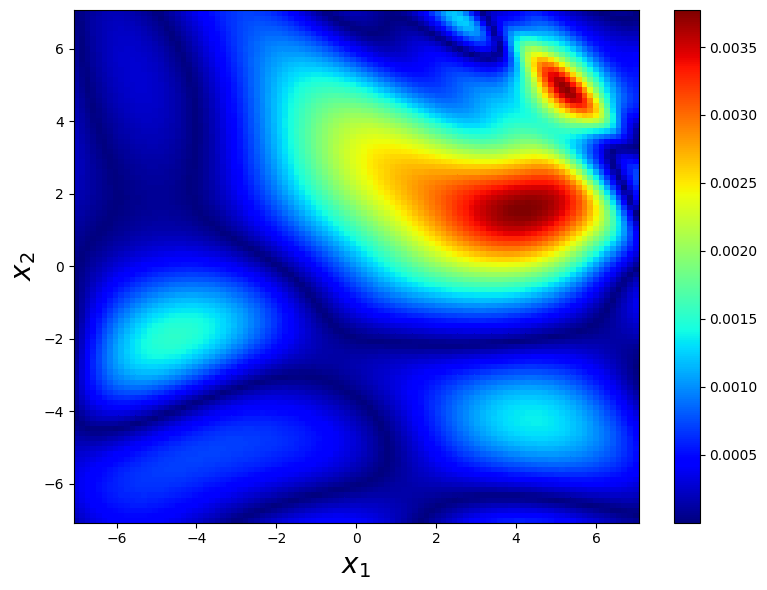


3. 绘制PDE残差分布（3张图）


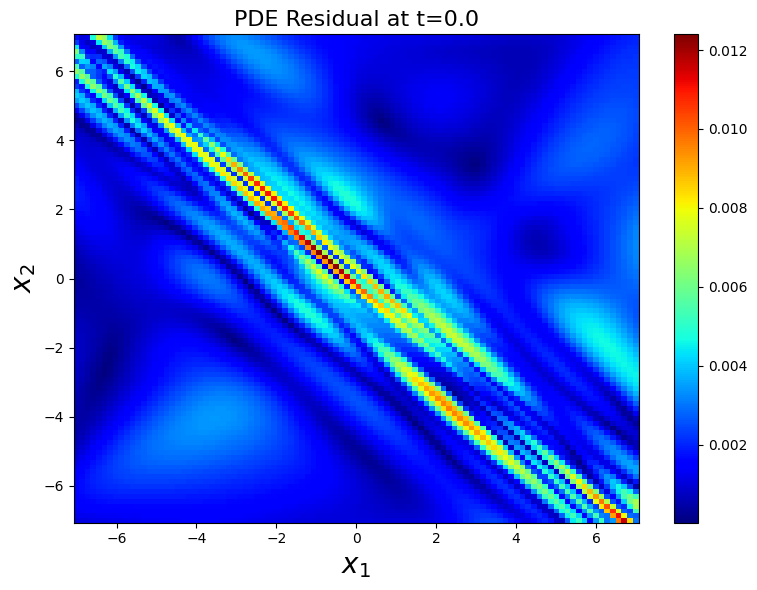

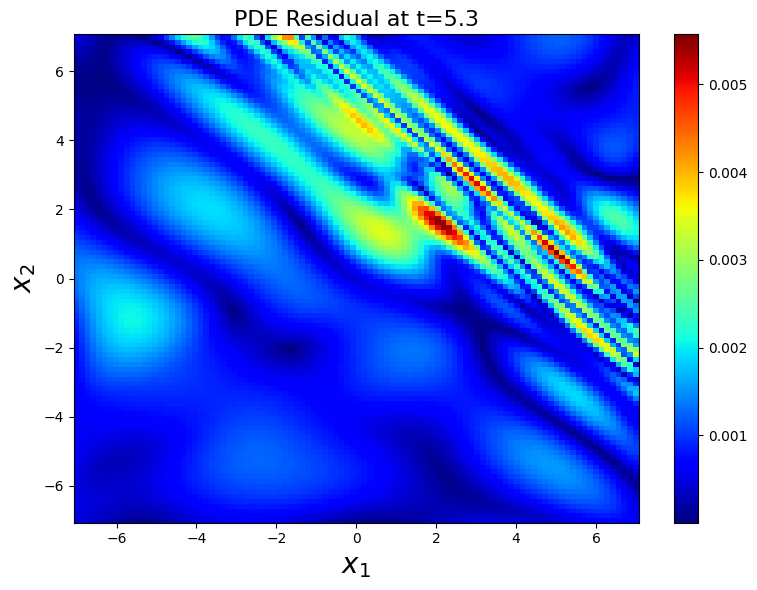

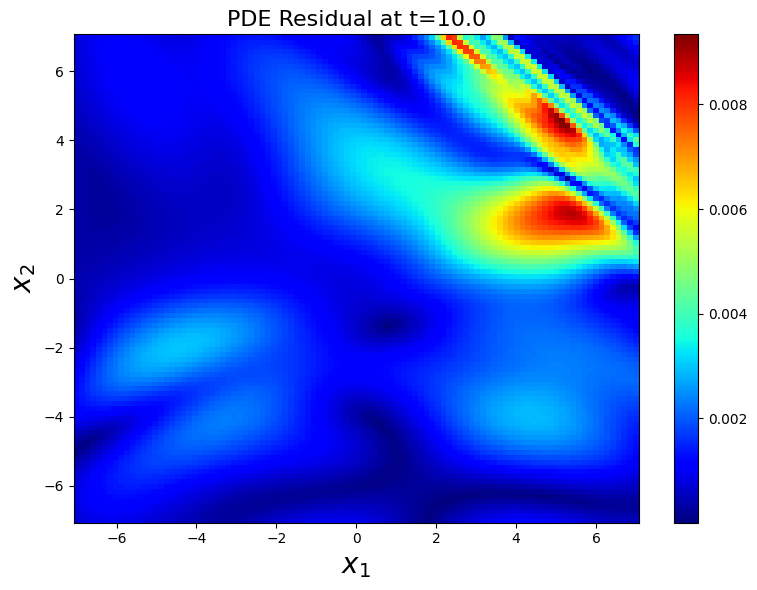


4. 绘制采样点分布（3张图）
t=0.0: 过滤后点数 = 361


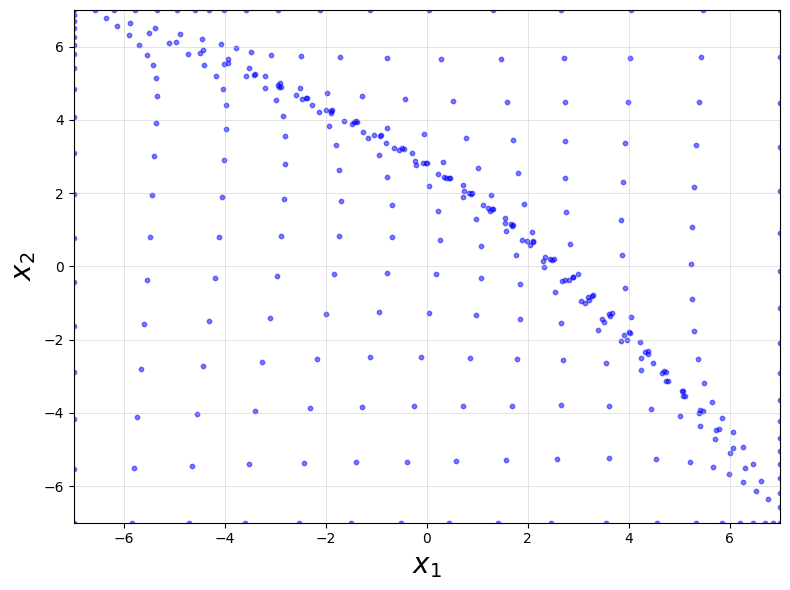

t=5.3: 过滤后点数 = 722


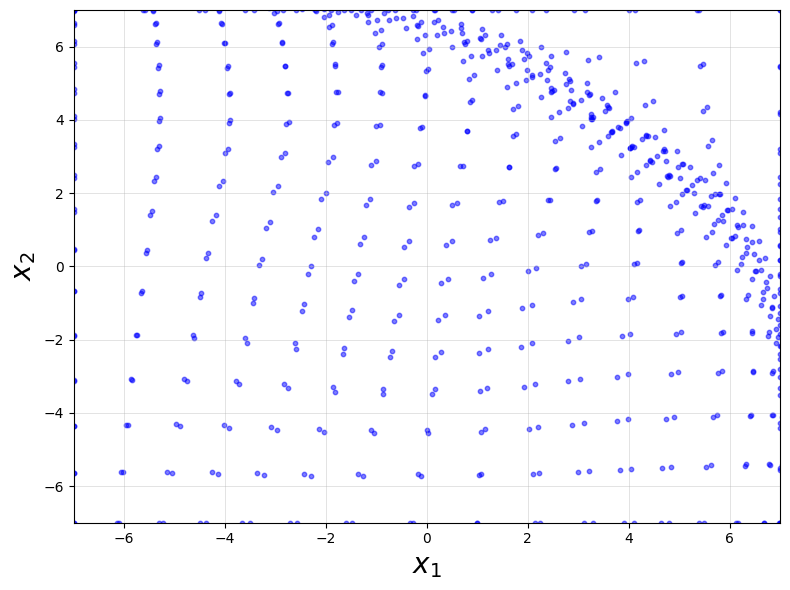

t=10.0: 过滤后点数 = 361


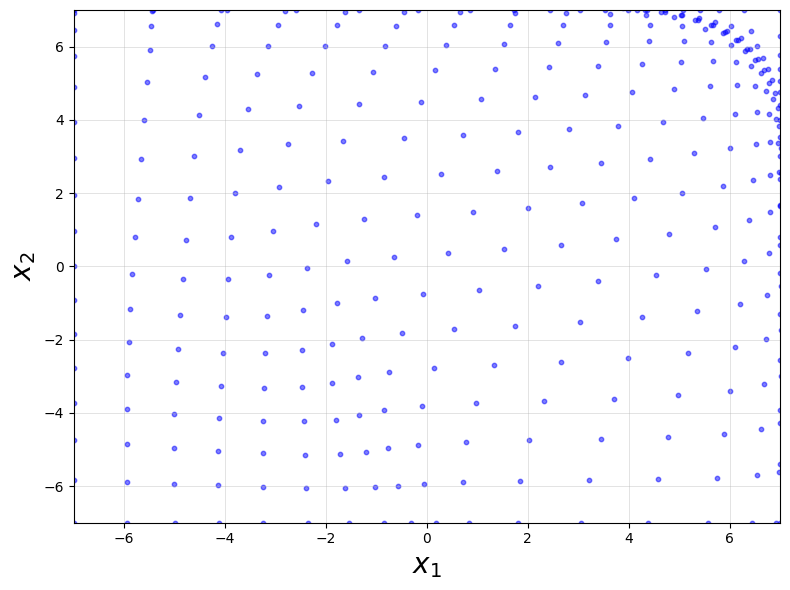


5. 计算L2相对误差
MMPDE-PINN 总体L2相对误差: 2.908758e-04

6. 计算能量演化
正在计算MMPDE-PINN能量演化...
进度: 1/50, t=0.00, E=212.852783
进度: 6/50, t=1.02, E=205.689606
进度: 11/50, t=2.04, E=191.054840
进度: 16/50, t=3.06, E=174.959045
进度: 21/50, t=4.08, E=158.675842
进度: 26/50, t=5.10, E=142.373810
进度: 31/50, t=6.12, E=126.065353
进度: 36/50, t=7.14, E=109.750763
进度: 41/50, t=8.16, E=93.431786
进度: 46/50, t=9.18, E=77.113007
能量数据已保存到 mmpde_pinn_energy_data.npz
能量数据已保存到 mmpde_pinn_energy_data.txt

正在计算精确解能量演化进行对比...
正在计算精确解能量演化...
进度: 1/50, t=0.00, E=212.909645
进度: 6/50, t=1.02, E=205.719083
进度: 11/50, t=2.04, E=191.079115
进度: 16/50, t=3.06, E=174.985357
进度: 21/50, t=4.08, E=158.689319
进度: 26/50, t=5.10, E=142.366755
进度: 31/50, t=6.12, E=126.040741
进度: 36/50, t=7.14, E=109.714285
进度: 41/50, t=8.16, E=93.387822
进度: 46/50, t=9.18, E=77.061749
能量数据已保存到 exact_energy_data_mmpde.npz
能量数据已保存到 exact_energy_data_mmpde.txt

7. 绘制能量相对误差对比图


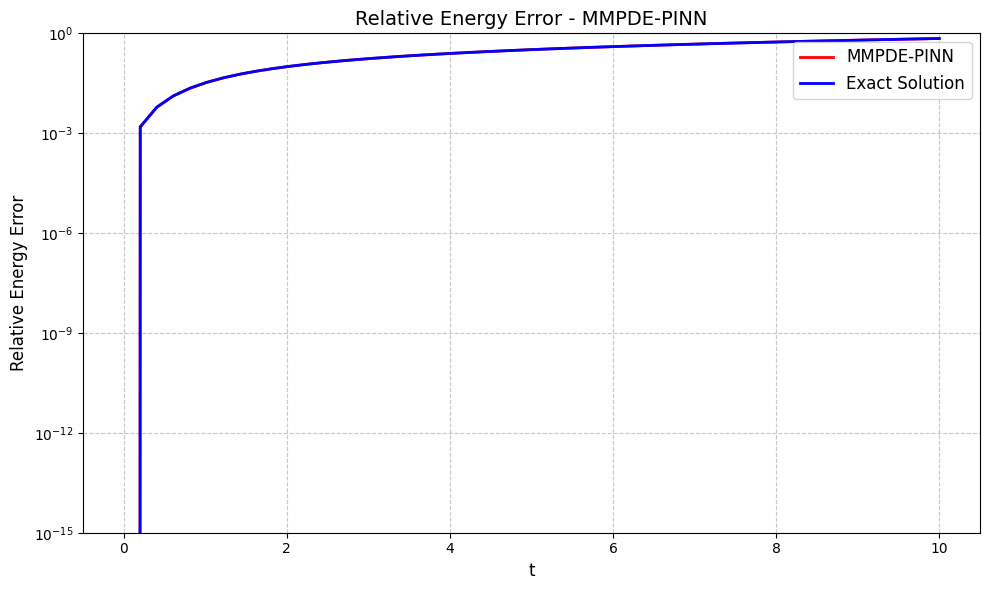


MMPDE-PINN能量统计:
初始能量 (t=0): 212.852783
最终能量 (t=10.0): 64.061295
能量变化: -69.903%
最大相对误差: 6.990347e-01
平均相对误差: 3.270231e-01

精确解能量统计:
初始能量 (t=0): 212.909645
最终能量 (t=10.0): 64.002683
能量变化: -69.939%
最大相对误差: 6.993904e-01
平均相对误差: 3.272310e-01

多时刻可视化完成！
总共生成图像：
- 精确解图像：3张
- 预测解图像：3张
- 误差分布图：3张
- 残差分布图：3张
- 采样点分布：3张
- 能量相对误差对比图：1张
总计：16张图像


In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 设备设置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

################################################################################
# 问题参数设置（与训练时保持一致）
################################################################################
Lx_min, Lx_max = -7.0, 7.0    
Ly_min, Ly_max = -7.0, 7.0    
T = 10.0                       # 修正：改为10.0以与训练代码一致
hidden_layers = 6             
neurons = 64                  

################################################################################
# 重新定义PINN网络结构
################################################################################
class PINN(nn.Module):
    def __init__(self, layers, activation=nn.Tanh()):
        super(PINN, self).__init__()
        
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        
        self.activation = activation
        
        # Initialize weights (Xavier initialization)
        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # Forward pass
        for i in range(len(self.linears) - 1):
            x = self.activation(self.linears[i](x))
        # output: [u, v] where v = u_t
        x = self.linears[-1](x)
        return x

################################################################################
# 精确解函数
################################################################################
def analytical_solution_u(x, y, t):
    """精确解: u(x,y,t) = 4*arctan(exp(x + y - t))"""
    return 4 * np.arctan(np.exp(x + y - t))

################################################################################
# 生成测试数据
################################################################################
def generate_test_data():
    """生成与第一个代码完全相同格式的测试数据"""
    
    # 修正：创建测试网格，时间范围改为0到10
    t = np.linspace(0, T, 20)  # 使用变量T而不是硬编码10
    x1 = np.linspace(-7, 7, 100)
    x2 = np.linspace(-7, 7, 100)

    T_grid, X1, X2 = np.meshgrid(t, x1, x2, indexing='ij')
    x_test_np = np.hstack((T_grid.flatten()[:, None], X1.flatten()[:, None], X2.flatten()[:, None]))

    # 计算精确解
    u_exact = analytical_solution_u(x_test_np[:, 1], x_test_np[:, 2], x_test_np[:, 0])
    
    # 转换为torch tensor
    x_test = torch.from_numpy(x_test_np).float().to(device)
    x_test_exact = torch.from_numpy(u_exact).float().to(device)
    
    return x_test, x_test_exact, t, x1, x2
def compute_energy_at_time_mmpde(model, t_value, x1_range=(-7, 7), x2_range=(-7, 7), num_points=100):
    """
    计算MMPDE-PINN模型在特定时刻t的能量
    使用更密集的网格点以提高积分精度
    """
    # 创建空间网格
    x1_grid = np.linspace(x1_range[0], x1_range[1], num_points)
    x2_grid = np.linspace(x2_range[0], x2_range[1], num_points)
    X1, X2 = np.meshgrid(x1_grid, x2_grid, indexing='ij')
    
    # 创建时空点 (t, x1, x2)
    t_grid = t_value * np.ones_like(X1)
    points = np.stack([t_grid.flatten(), X1.flatten(), X2.flatten()], axis=1)
    points_tensor = torch.tensor(points, dtype=torch.float32, device=device)
    
    # 计算 u 及其导数
    points_tensor.requires_grad_(True)
    model.eval()
    
    uv = model(points_tensor)
    u = uv[:, [0]]  # displacement u
    v = uv[:, [1]]  # velocity v = u_t
    
    # 计算空间导数
    grad_u = torch.autograd.grad(u, points_tensor, 
                                grad_outputs=torch.ones_like(u), 
                                create_graph=True)[0]
    
    u_x1 = grad_u[:, 1]  # ∂u/∂x1  
    u_x2 = grad_u[:, 2]  # ∂u/∂x2
    
    # v就是u_t，所以u_t = v
    u_t = v.squeeze()  # velocity v = u_t
    
    # 计算能量密度：E = 0.5 * (u_t² + u_x1² + u_x2² + 2(1 - cos(u)))
    energy_density = 0.5 * (u_t**2 + u_x1**2 + u_x2**2 + 2*(1 - torch.cos(u.squeeze())))
    
    # 重塑为网格形状
    energy_density = energy_density.reshape(num_points, num_points)
    
    # 数值积分计算总能量 (使用梯形法则)
    dx1 = (x1_range[1] - x1_range[0]) / (num_points - 1)
    dx2 = (x2_range[1] - x2_range[0]) / (num_points - 1)
    
    total_energy = torch.trapz(torch.trapz(energy_density, dim=1), dim=0) * dx1 * dx2
    
    return total_energy.cpu().detach().numpy().item()

def compute_energy_evolution_mmpde(model, t_array):
    """
    计算MMPDE-PINN能量随时间的演化，并计算相对误差
    """
    energies = []
    print("正在计算MMPDE-PINN能量演化...")
    
    for i, t_val in enumerate(t_array):
        energy = compute_energy_at_time_mmpde(model, t_val)
        energies.append(energy)
        if i % 5 == 0:  # 每5个点打印一次进度
            print(f"进度: {i+1}/{len(t_array)}, t={t_val:.2f}, E={energy:.6f}")
    
    energies = np.array(energies)
    E0 = energies[0]  # 初始能量
    
    # 计算相对误差
    rel_errors = np.abs(energies - E0) / E0
    
    return energies, rel_errors, E0
def compute_energy_at_time_eems_viz(model, t_value, x1_range=(-7, 7), x2_range=(-7, 7), num_points=50):
    """
    计算MMPDE-PINN模型在特定时刻t的能量（可视化版本，保持向后兼容）
    """
    return compute_energy_at_time_mmpde(model, t_value, x1_range, x2_range, num_points)

def compute_energy_evolution_eems_viz(model, t_array):
    """
    计算MMPDE-PINN能量随时间的演化（可视化版本，保持向后兼容）
    """
    energies, _, _ = compute_energy_evolution_mmpde(model, t_array)
    return energies
def compute_exact_energy_evolution(t_array):
    """
    计算精确解的能量演化作为参考
    """
    def u_exact(x1, x2, t):
        return 4 * np.arctan(np.exp(x1 + x2 - t))
    
    def u_t_exact(x1, x2, t):
        exp_term = np.exp(x1 + x2 - t)
        return -4 * exp_term / (1 + exp_term**2)
    
    def u_x1_exact(x1, x2, t):
        exp_term = np.exp(x1 + x2 - t)
        return 4 * exp_term / (1 + exp_term**2)
    
    def u_x2_exact(x1, x2, t):
        return u_x1_exact(x1, x2, t)  # 对称性
    
    def energy_density(x1, x2, t):
        u = u_exact(x1, x2, t)
        ut = u_t_exact(x1, x2, t)
        ux1 = u_x1_exact(x1, x2, t)
        ux2 = u_x2_exact(x1, x2, t)
        return 0.5 * (ut**2 + ux1**2 + ux2**2 + 2*(1 - np.cos(u)))
    
    def compute_energy(t):
        return dblquad(energy_density, -7, 7, lambda x: -7, lambda x: 7, args=(t,))[0]
    
    print("正在计算精确解能量演化...")
    energies = []
    for i, t in enumerate(t_array):
        E_t = compute_energy(t)
        energies.append(E_t)
        if i % 5 == 0:
            print(f"进度: {i+1}/{len(t_array)}, t={t:.2f}, E={E_t:.6f}")
    
    energies = np.array(energies)
    E0 = energies[0]
    rel_errors = np.abs(energies - E0) / E0
    
    return energies, rel_errors, E0

def plot_energy_comparison_mmpde(t_array, mmpde_energies, mmpde_rel_errors, exact_energies=None, exact_rel_errors=None):
    """
    绘制能量相对误差对比图（MMPDE版本）
    """
    plt.figure(figsize=(10, 6))
    
    # 绘制MMPDE-PINN的相对误差
    plt.semilogy(t_array, mmpde_rel_errors, 'r-', linewidth=2, label='MMPDE-PINN')
    
    # 如果有精确解数据，也绘制出来
    if exact_rel_errors is not None:
        plt.semilogy(t_array, exact_rel_errors, 'b-', linewidth=2, label='Exact Solution')
    
    # 设置图表格式
    plt.title('Relative Energy Error - MMPDE-PINN', fontsize=14)
    plt.xlabel('t', fontsize=12)
    plt.ylabel('Relative Energy Error', fontsize=12)
    plt.xticks(np.arange(0, int(t_array[-1])+1, 2))
    
    # 动态设置y轴刻度
    all_errors = [mmpde_rel_errors]
    if exact_rel_errors is not None:
        all_errors.append(exact_rel_errors)
    
    min_error = min([np.min(err) for err in all_errors])
    max_error = max([np.max(err) for err in all_errors])
    
    if min_error < 1e-12:
        plt.yticks([1e-15, 1e-12, 1e-9, 1e-6, 1e-3, 1e-0])
    elif min_error < 1e-9:
        plt.yticks([1e-12, 1e-9, 1e-6, 1e-3, 1e-0])
    else:
        plt.yticks([1e-9, 1e-6, 1e-3, 1e-0])
    
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

def save_energy_data_mmpde(filename, t_array, energies, rel_errors, E0, method_name="MMPDE-PINN"):
    """
    保存MMPDE能量数据到文件
    """
    data = {
        'time': t_array,
        'energies': energies, 
        'relative_errors': rel_errors,
        'initial_energy': E0,
        'method': method_name
    }
    np.savez(filename, **data)
    print(f"能量数据已保存到 {filename}")
    
    # 同时保存为文本文件便于查看
    txt_filename = filename.replace('.npz', '.txt')
    with open(txt_filename, 'w') as f:
        f.write(f"# {method_name} Energy Evolution Data\n")
        f.write(f"# Initial Energy: {E0:.10e}\n")
        f.write("# Time\tEnergy\tRelative_Error\n")
        for t, E, rel_err in zip(t_array, energies, rel_errors):
            f.write(f"{t:.6f}\t{E:.10e}\t{rel_err:.10e}\n")
    print(f"能量数据已保存到 {txt_filename}")
################################################################################
# 多时刻可视化函数
################################################################################

def draw_exact_multi_time(model, x_test, x_test_exact, t, x1, x2, time_indices=[0, 10, 19]):
    """
    绘制多个时刻的精确解与MMPDE-PINN解对比
    修正：time_indices对应t=0, t=5, t=10时刻
    """
    model.eval()
    with torch.no_grad():
        uv_pred = model(x_test)
        predict_np = uv_pred[:, [0]].cpu().detach().numpy()  # 只取u分量
    
    u_test_np = x_test_exact.cpu().detach().numpy()
    u_test_np = u_test_np.flatten()[:, None]
    
    # 重塑为3D数组：(时间, x1, x2)
    e_u = np.reshape(u_test_np, (len(t), len(x1), len(x2)))
    pred_u = np.reshape(predict_np, (len(t), len(x1), len(x2)))
    
    XX1, XX2 = np.meshgrid(x1, x2, indexing='ij')
    
    # 修正：对应的时刻值和标签
    time_values = [t[idx] for idx in time_indices]
    time_labels = [f't={time_val:.1f}' for time_val in time_values]  # 动态生成标签
    
    for i, (time_idx, time_val, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
        # 精确解
        plt.figure(figsize=(8, 6))
        e = e_u[time_idx, :, :]
        plt.pcolor(XX1, XX2, e, cmap='jet', shading='auto')
        plt.colorbar()
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)

        plt.tight_layout()
        plt.show()
        
        # MMPDE预测解
        plt.figure(figsize=(8, 6))
        pred = pred_u[time_idx, :, :]
        plt.pcolor(XX1, XX2, pred, cmap='jet', shading='auto')
        plt.colorbar()
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)

        plt.tight_layout()
        plt.show()

def draw_error_multi_time(model, x_test, x_test_exact, t, x1, x2, time_indices=[0, 10, 19]):
    """绘制多个时刻的误差分布图"""
    model.eval()
    with torch.no_grad():
        uv_pred = model(x_test)
        predict_np = uv_pred[:, [0]].cpu().detach().numpy()  # 只取u分量
    
    u_test_np = x_test_exact.cpu().detach().numpy()
    u_test_np = u_test_np.flatten()[:, None]
    error_u = np.abs(predict_np - u_test_np)
    
    error_u = np.reshape(error_u, (len(t), len(x1), len(x2)))
    X1, X2 = np.meshgrid(x1, x2, indexing='ij')
    
    # 修正：对应的时刻值和标签
    time_values = [t[idx] for idx in time_indices]
    time_labels = [f't={time_val:.1f}' for time_val in time_values]
    
    for i, (time_idx, time_val, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
        plt.figure(figsize=(8, 6))
        plt.pcolor(X1, X2, error_u[time_idx, :, :], cmap='jet', shading='auto')
        plt.colorbar()
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)

        plt.tight_layout()
        plt.show()

def draw_residual_multi_time(model, x_test, t, x1, x2, time_indices=[0, 10, 19]):
    """绘制多个时刻的PDE残差分布图"""
    model.eval()
    
    # 计算PDE残差
    t_tensor = x_test[:, [0]].clone().detach().requires_grad_(True)
    x_tensor = x_test[:, [1]].clone().detach().requires_grad_(True)
    y_tensor = x_test[:, [2]].clone().detach().requires_grad_(True)
    
    inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
    uv = model(inputs)
    u = uv[:, [0]]
    v = uv[:, [1]]
    
    # 计算一阶导数
    u_grads = torch.autograd.grad(u, inputs, 
                                 grad_outputs=torch.ones_like(u), 
                                 create_graph=True)[0]
    u_t = u_grads[:, [0]]
    u_x = u_grads[:, [1]]
    u_y = u_grads[:, [2]]

    # 计算二阶导数
    u_xx = torch.autograd.grad(u_x, x_tensor,
                              grad_outputs=torch.ones_like(u_x),
                              create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_tensor,
                              grad_outputs=torch.ones_like(u_y),
                              create_graph=True)[0]

    # PDE残差: du/dt - v 和 dv/dt - (u_xx + u_yy - sin(u))
    v_grads = torch.autograd.grad(v, inputs,
                                 grad_outputs=torch.ones_like(v),
                                 create_graph=True)[0]
    v_t = v_grads[:, [0]]
    
    f_u = u_t - v
    f_v = v_t - (u_xx + u_yy - torch.sin(u))
    
    # 总残差
    total_residual = torch.sqrt(f_u**2 + f_v**2)
    f_u_np = total_residual.cpu().detach().numpy()

    residual = np.reshape(np.abs(f_u_np), (len(t), len(x1), len(x2)))
    X1, X2 = np.meshgrid(x1, x2, indexing='ij')
    
    # 修正：对应的时刻值和标签
    time_values = [t[idx] for idx in time_indices]
    time_labels = [f't={time_val:.1f}' for time_val in time_values]
    
    for i, (time_idx, time_val, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
        plt.figure(figsize=(8, 6))
        plt.pcolor(X1, X2, residual[time_idx, :, :], cmap='jet', shading='auto')
        plt.colorbar()
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)
        plt.title(f'PDE Residual at {time_label}', fontsize=16)
        plt.tight_layout()
        plt.show()

def draw_sampling_points_multi_time(sampling_points_history, t, x1, x2, time_indices=[0, 10, 19]):
    """绘制多个时刻的采样点分布"""
    
    # 修正：对应的时刻值和标签
    time_values = [t[idx] for idx in time_indices]
    time_labels = [f't={time_val:.1f}' for time_val in time_values]
    
    if not sampling_points_history:
        print("警告：没有采样点历史数据，生成模拟采样点...")
        # 生成模拟采样点
        for i, (time_idx, time_val, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
            # 生成一些集中在特定区域的点（模拟自适应采样效果）
            n_points = 500
            
            # 根据不同时刻调整采样模式
            if time_idx == 0:  # t=0
                # 初始时刻，较多中心区域采样
                center_points_x1 = np.random.normal(0, 2, (n_points//2, 1))
                center_points_x2 = np.random.normal(0, 2, (n_points//2, 1))
                edge_points_x1 = np.random.uniform(-6, 6, (n_points//2, 1))
                edge_points_x2 = np.random.uniform(-6, 6, (n_points//2, 1))
            else:
                # 后续时刻，更多边界采样
                center_points_x1 = np.random.normal(0, 1.5, (n_points//3, 1))
                center_points_x2 = np.random.normal(0, 1.5, (n_points//3, 1))
                edge_points_x1 = np.random.choice([-6, -5, 5, 6], 2*n_points//3).reshape(-1, 1) + np.random.normal(0, 0.8, (2*n_points//3, 1))
                edge_points_x2 = np.random.uniform(-6, 6, (2*n_points//3, 1))
            
            # 合并和限制点
            all_x1 = np.vstack([center_points_x1, edge_points_x1])
            all_x2 = np.vstack([center_points_x2, edge_points_x2])
            all_x1 = np.clip(all_x1, -7, 7)
            all_x2 = np.clip(all_x2, -7, 7)
            
            # 绘制
            plt.figure(figsize=(8, 6))
            plt.scatter(all_x1, all_x2, c='blue', s=10, alpha=0.5)
            plt.xlim(-7, 7)
            plt.ylim(-7, 7)
            plt.xlabel(r'$x_1$', fontsize=20)
            plt.ylabel(r'$x_2$', fontsize=20)

            plt.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
            plt.tight_layout()
            plt.show()
        return
    
    # 使用真实的采样点历史
    last_sampling = sampling_points_history[-1]
    title, points = last_sampling
    
    for i, (time_idx, target_time, time_label) in enumerate(zip(time_indices, time_values, time_labels)):
        # 修正：时间过滤，使用更合适的容忍度
        time_tolerance = (t[-1] - t[0]) / 20  # 调整容忍度，考虑T=10的范围
        
        # 过滤采样点
        M_mask = np.abs(points[:, 0] - target_time) < time_tolerance
        M_points_at_time = points[M_mask]
        
        print(f"{time_label}: 过滤后点数 = {len(M_points_at_time)}")
        
        # 如果过滤后点数太少，使用全部点并按时间着色
        if len(M_points_at_time) < 20:
            print(f"{time_label}: 点数过少，使用全部采样点")
            M_points_at_time = points
            colors = M_points_at_time[:, 0]  # 时间着色
            scatter_kwargs = {'c': colors, 'cmap': 'viridis', 's': 10, 'alpha': 0.7}
        else:
            scatter_kwargs = {'c': 'blue', 's': 10, 'alpha': 0.5}
        
        # 绘制
        plt.figure(figsize=(8, 6))
        if len(M_points_at_time) > 0:
            scatter = plt.scatter(M_points_at_time[:, 1], M_points_at_time[:, 2], **scatter_kwargs)
            
            # 如果使用了时间着色，添加colorbar
            if 'c' in scatter_kwargs and not isinstance(scatter_kwargs['c'], str):
                plt.colorbar(scatter, label='Time')
        
        plt.xlim(-7, 7)
        plt.ylim(-7, 7)
        plt.xlabel(r'$x_1$', fontsize=20)
        plt.ylabel(r'$x_2$', fontsize=20)

        plt.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.show()

################################################################################
# 主要可视化函数
################################################################################
def visualize_mmpde_multi_time(trained_model=None, training_history=None, time_points=None):
    """
    多时刻MMPDE可视化（修改后的版本）
    修正：支持自定义时间点，默认为t=0, t=5, t=10
    
    Parameters:
    -----------
    time_points : list, optional
        要可视化的时间点列表，例如 [0, 5, 10] 或 [0, 2.5, 5, 7.5, 10]
    """
    
    print("=" * 80)
    print(f"MMPDE-PINN 多时刻可视化 (T={T})")
    print("=" * 80)
    
    # 生成测试数据
    print("生成测试数据...")
    x_test, x_test_exact, t, x1, x2 = generate_test_data()
    print(f"测试数据生成完成：{len(x_test)} 个测试点")
    print(f"时间范围：[{t[0]:.1f}, {t[-1]:.1f}]，共{len(t)}个时间点")
    
    # 确定时间索引
    if time_points is None:
        # 默认时间点：开始、中间、结束
        time_points = [0, T/2, T]
    
    # 找到最接近目标时间点的索引
    time_indices = []
    actual_times = []
    for target_time in time_points:
        idx = np.argmin(np.abs(t - target_time))
        time_indices.append(idx)
        actual_times.append(t[idx])
    
    print(f"目标时间点：{time_points}")
    print(f"实际时间点：{[f'{t:.1f}' for t in actual_times]} (索引: {time_indices})")
    
    # 加载模型（如果需要）
    if trained_model is None:
        try:
            checkpoint = torch.load('mmpde_pinn_complete.pth', map_location=device)
            
            layers = [3, 64, 64, 64, 64, 64, 64, 2]
            trained_model = PINN(layers, activation=nn.Tanh()).to(device)
            trained_model.load_state_dict(checkpoint['model_state_dict'])
            training_history = checkpoint['training_history']
            
            print("模型加载成功！")
            
        except:
            try:
                layers = [3, 64, 64, 64, 64, 64, 64, 2]
                trained_model = PINN(layers, activation=nn.Tanh()).to(device)
                trained_model.load_state_dict(torch.load('mmpde_pinn_model.pth', map_location=device))
                print("模型参数加载成功！（没有训练历史）")
            except:
                print("无法加载模型，将跳过需要模型的绘图")
                return
    
    # 1. 绘制精确解与预测解
    print(f"\n1. 绘制精确解与预测解（{len(time_indices)}个时刻 × 2张图 = {len(time_indices)*2}张图）")
    if trained_model is not None:
        draw_exact_multi_time(trained_model, x_test, x_test_exact, t, x1, x2, time_indices)
    
    # 2. 绘制误差分布
    print(f"\n2. 绘制误差分布（{len(time_indices)}张图）")
    if trained_model is not None:
        draw_error_multi_time(trained_model, x_test, x_test_exact, t, x1, x2, time_indices)
    
    # 3. 绘制PDE残差
    print(f"\n3. 绘制PDE残差分布（{len(time_indices)}张图）")
    if trained_model is not None:
        draw_residual_multi_time(trained_model, x_test, t, x1, x2, time_indices)
    
    # 4. 绘制采样点分布
    print(f"\n4. 绘制采样点分布（{len(time_indices)}张图）")
    if training_history and 'sampling_points_history' in training_history:
        sampling_history = training_history['sampling_points_history']
        draw_sampling_points_multi_time(sampling_history, t, x1, x2, time_indices)
    else:
        print("没有采样点历史，生成模拟采样点...")
        draw_sampling_points_multi_time(None, t, x1, x2, time_indices)
    
    # 5. 计算并显示L2误差
    print("\n5. 计算L2相对误差")
    if trained_model is not None:
        trained_model.eval()
        with torch.no_grad():
            uv_pred = trained_model(x_test)
            pred = uv_pred[:, [0]].cpu().detach().numpy()
            exact = x_test_exact.cpu().detach().numpy().flatten()[:, None]
            error = np.linalg.norm(pred - exact, 2) / np.linalg.norm(exact, 2)
            print(f"MMPDE-PINN 总体L2相对误差: {error:.6e}")
    
    # 6. 计算能量演化（修改后的部分）
    print("\n6. 计算能量演化")
    if trained_model is not None:
        t_energy = np.linspace(0, T, 50)  # 50个时间点，减少计算量
        
        # 计算MMPDE-PINN能量演化
        mmpde_energies, mmpde_rel_errors, mmpde_E0 = compute_energy_evolution_mmpde(trained_model, t_energy)
        
        # 保存MMPDE能量数据
        save_energy_data_mmpde('mmpde_pinn_energy_data.npz', t_energy, mmpde_energies, mmpde_rel_errors, mmpde_E0, 'MMPDE-PINN')
        
        # 可选：计算精确解能量演化进行对比（时间较长，可注释掉）
        print("\n正在计算精确解能量演化进行对比...")
        exact_energies, exact_rel_errors, exact_E0 = compute_exact_energy_evolution(t_energy)
        save_energy_data_mmpde('exact_energy_data_mmpde.npz', t_energy, exact_energies, exact_rel_errors, exact_E0, 'Exact')
        
        # 绘制能量相对误差对比图
        print("\n7. 绘制能量相对误差对比图")
        plot_energy_comparison_mmpde(t_energy, mmpde_energies, mmpde_rel_errors, exact_energies, exact_rel_errors)
        
        # 显示能量统计信息
        print(f"\nMMPDE-PINN能量统计:")
        print(f"初始能量 (t=0): {mmpde_E0:.6f}")
        print(f"最终能量 (t={t_energy[-1]}): {mmpde_energies[-1]:.6f}")
        print(f"能量变化: {((mmpde_energies[-1] - mmpde_E0)/mmpde_E0*100):.3f}%")
        print(f"最大相对误差: {np.max(mmpde_rel_errors):.6e}")
        print(f"平均相对误差: {np.mean(mmpde_rel_errors):.6e}")
        
        if exact_energies is not None:
            print(f"\n精确解能量统计:")
            print(f"初始能量 (t=0): {exact_E0:.6f}")
            print(f"最终能量 (t={t_energy[-1]}): {exact_energies[-1]:.6f}")
            print(f"能量变化: {((exact_energies[-1] - exact_E0)/exact_E0*100):.3f}%")
            print(f"最大相对误差: {np.max(exact_rel_errors):.6e}")
            print(f"平均相对误差: {np.mean(exact_rel_errors):.6e}")
        
        # 保存到全局变量（供后续使用）
        global mmpde_pinn_energy_data
        mmpde_pinn_energy_data = {
            't_array': t_energy, 
            'energies': mmpde_energies,
            'relative_errors': mmpde_rel_errors,
            'initial_energy': mmpde_E0,
            'method': 'MMPDE-PINN'
        }
    
    print("\n" + "=" * 80)
    print("多时刻可视化完成！")
    print("总共生成图像：")
    print(f"- 精确解图像：{len(time_indices)}张")
    print(f"- 预测解图像：{len(time_indices)}张") 
    print(f"- 误差分布图：{len(time_indices)}张")
    print(f"- 残差分布图：{len(time_indices)}张")
    print(f"- 采样点分布：{len(time_indices)}张")
    print(f"- 能量相对误差对比图：1张")
    print(f"总计：{len(time_indices)*5 + 1}张图像")
    print("=" * 80)

################################################################################
# 使用方法
################################################################################

if __name__ == "__main__":
    # 如果你刚运行完训练：
    # visualize_mmpde_multi_time(trained_model, training_history)
    
    # 从文件加载（默认时间点：t=0, 5, 10）：
    visualize_mmpde_multi_time()
    
    # 自定义时间点：
    # visualize_mmpde_multi_time(time_points=[0, 2.5, 5, 7.5, 10])
    
    # 只看3个关键时刻：
    # visualize_mmpde_multi_time(time_points=[0, 5, 10])

EEMS-PINN 能量分析可视化

加载数据文件: eems_pinn_energy_viz.npy

1. 绘制详细分析图...
成功加载数据文件: eems_pinn_energy_viz.npy
数据信息:
- 方法: EEMS-PINN
- 时间点数: 20
- 时间范围: [0.00, 10.00]
- 初始能量: 212.668869
- 最终能量: 63.779308
图片已保存为:
- eems_pinn_energy_analysis.png
- eems_pinn_energy_analysis.pdf


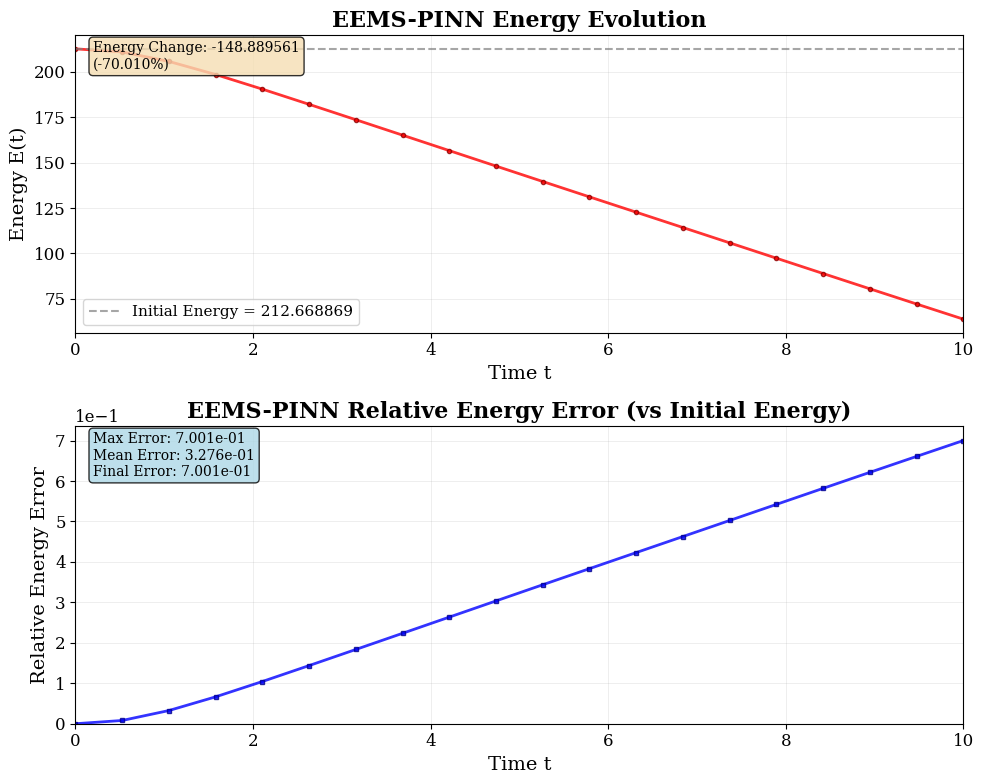


EEMS-PINN 能量分析统计
初始能量 E(0):        212.66886902
最终能量 E(10.0):        63.77930832
绝对能量变化:        -148.88956070
相对能量变化:        -70.010040%
----------------------------------------------------------------------
相对误差统计 (相对于初始能量):
最大相对误差:        7.001004e-01
平均相对误差:        3.275737e-01
最终相对误差:        7.001004e-01
标准差:             2.228211e-01

2. 绘制简化版相对误差图...
简化版图片已保存为:
- eems_pinn_relative_energy.png
- eems_pinn_relative_energy.pdf


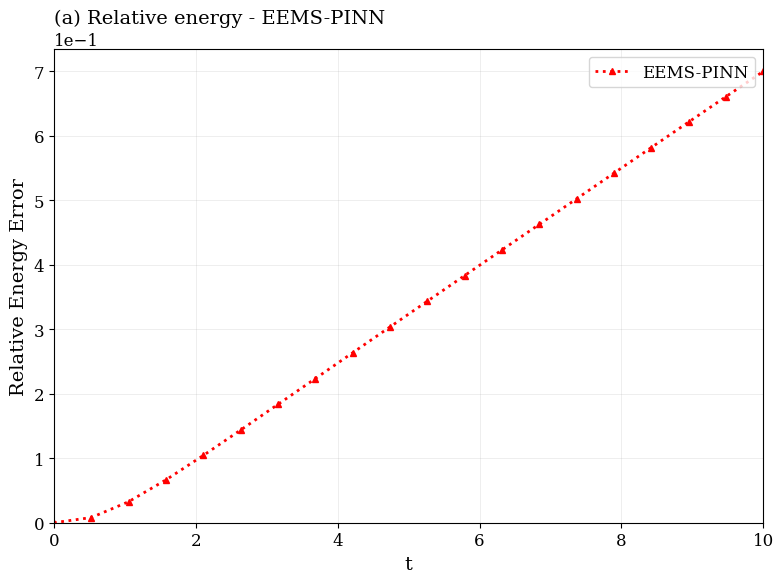


绘制完成！


"\n使用说明:\n1. 确保你已经运行了EEMS-PINN代码并生成了 'eems_pinn_energy_viz.npy' 文件\n2. 直接运行本脚本即可生成两种风格的图:\n   - 详细分析图: 包含能量变化曲线和相对误差\n   - 简化版图: 只有相对误差图，与你的参考图片风格一致\n3. 图片会自动保存为PNG和PDF格式\n"

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 设置字体以支持数学符号
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
rcParams['mathtext.fontset'] = 'stix'

def plot_eems_energy_analysis(data_file='eems_pinn_energy_viz.npy', save_figure=True):
    """
    绘制EEMS-PINN的能量变化曲线和相对误差图
    
    Parameters:
    -----------
    data_file : str
        能量数据文件路径
    save_figure : bool
        是否保存图片
    """
    
    # 加载数据
    try:
        eems_data = np.load(data_file, allow_pickle=True).item()
        print(f"成功加载数据文件: {data_file}")
    except:
        print(f"无法加载文件: {data_file}")
        return
    
    # 提取时间和能量数据
    t_array = eems_data['t_array']
    energies = eems_data['energies']
    method = eems_data.get('method', 'EEMS-PINN')
    
    print(f"数据信息:")
    print(f"- 方法: {method}")
    print(f"- 时间点数: {len(t_array)}")
    print(f"- 时间范围: [{t_array[0]:.2f}, {t_array[-1]:.2f}]")
    print(f"- 初始能量: {energies[0]:.6f}")
    print(f"- 最终能量: {energies[-1]:.6f}")
    
    # 计算相对于初始能量的相对误差
    initial_energy = energies[0]
    relative_error = np.abs(energies - initial_energy) / np.abs(initial_energy)
    
    # 创建双子图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # ==================== 第一个子图：能量变化曲线 ====================
    ax1.plot(t_array, energies, 'r-', linewidth=2, marker='o', markersize=3, 
             markerfacecolor='red', markeredgecolor='darkred', alpha=0.8)
    
    # 添加初始能量的水平参考线
    ax1.axhline(y=initial_energy, color='gray', linestyle='--', alpha=0.7, 
                label=f'Initial Energy = {initial_energy:.6f}')
    
    ax1.set_xlabel('Time t', fontsize=14)
    ax1.set_ylabel('Energy E(t)', fontsize=14)
    ax1.set_title('EEMS-PINN Energy Evolution', fontsize=16, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.legend(fontsize=11)
    
    # 设置坐标轴范围
    ax1.set_xlim(t_array[0], t_array[-1])
    
    # 添加能量变化的数值信息
    energy_change = energies[-1] - energies[0]
    energy_change_percent = (energy_change / initial_energy) * 100
    
    # 在图上添加文本信息
    ax1.text(0.02, 0.98, f'Energy Change: {energy_change:+.6f}\n({energy_change_percent:+.3f}%)', 
             transform=ax1.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # ==================== 第二个子图：相对误差 ====================
    ax2.plot(t_array, relative_error, 'b-', linewidth=2, marker='s', markersize=3,
             markerfacecolor='blue', markeredgecolor='darkblue', alpha=0.8)
    
    ax2.set_xlabel('Time t', fontsize=14)
    ax2.set_ylabel('Relative Energy Error', fontsize=14)
    ax2.set_title('EEMS-PINN Relative Energy Error (vs Initial Energy)', fontsize=16, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # 设置坐标轴范围
    ax2.set_xlim(t_array[0], t_array[-1])
    ax2.set_ylim(bottom=0)
    
    # 使用科学计数法显示y轴
    ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # 添加统计信息
    max_error = np.max(relative_error)
    mean_error = np.mean(relative_error)
    final_error = relative_error[-1]
    
    # 在图上添加统计信息
    stats_text = f'Max Error: {max_error:.3e}\nMean Error: {mean_error:.3e}\nFinal Error: {final_error:.3e}'
    ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, fontsize=10, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # 调整子图间距
    plt.tight_layout()
    
    # 保存图片
    if save_figure:
        plt.savefig('eems_pinn_energy_analysis.png', dpi=300, bbox_inches='tight')
        plt.savefig('eems_pinn_energy_analysis.pdf', bbox_inches='tight')
        print("图片已保存为:")
        print("- eems_pinn_energy_analysis.png")
        print("- eems_pinn_energy_analysis.pdf")
    
    plt.show()
    
    # 打印详细统计信息
    print("\n" + "="*70)
    print("EEMS-PINN 能量分析统计")
    print("="*70)
    print(f"初始能量 E(0):        {initial_energy:.8f}")
    print(f"最终能量 E({t_array[-1]:.1f}):        {energies[-1]:.8f}")
    print(f"绝对能量变化:        {energy_change:+.8f}")
    print(f"相对能量变化:        {energy_change_percent:+.6f}%")
    print("-"*70)
    print("相对误差统计 (相对于初始能量):")
    print(f"最大相对误差:        {max_error:.6e}")
    print(f"平均相对误差:        {mean_error:.6e}")
    print(f"最终相对误差:        {final_error:.6e}")
    print(f"标准差:             {np.std(relative_error):.6e}")
    print("="*70)
    
    return {
        't_array': t_array,
        'energies': energies,
        'initial_energy': initial_energy,
        'final_energy': energies[-1],
        'energy_change': energy_change,
        'energy_change_percent': energy_change_percent,
        'relative_error': relative_error,
        'max_error': max_error,
        'mean_error': mean_error,
        'final_error': final_error
    }

def plot_eems_energy_simple(data_file='eems_pinn_energy_viz.npy', save_figure=True):
    """
    绘制简化版的EEMS-PINN能量图（单独的相对误差图，与参考图片风格一致）
    """
    
    # 加载数据
    try:
        eems_data = np.load(data_file, allow_pickle=True).item()
    except:
        print(f"无法加载文件: {data_file}")
        return
    
    # 提取数据
    t_array = eems_data['t_array']
    energies = eems_data['energies']
    
    # 计算相对误差
    initial_energy = energies[0]
    relative_error = np.abs(energies - initial_energy) / np.abs(initial_energy)
    
    # 创建单一图形，模仿参考图片风格
    plt.figure(figsize=(8, 6))
    
    # 绘制相对误差曲线
    plt.plot(t_array, relative_error, 'r:', linewidth=2, label='EEMS-PINN', 
             marker='^', markersize=4)
    
    # 设置坐标轴
    plt.xlabel('t', fontsize=14)
    plt.ylabel('Relative Energy Error', fontsize=14)
    plt.title('(a) Relative energy - EEMS-PINN', fontsize=14, loc='left')
    
    # 设置网格
    plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # 设置图例
    plt.legend(fontsize=12, loc='upper right')
    
    # 设置坐标轴范围
    plt.xlim(t_array[0], t_array[-1])
    plt.ylim(bottom=0)
    
    # 使用科学计数法显示y轴
    plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # 调整布局
    plt.tight_layout()
    
    # 保存图片
    if save_figure:
        plt.savefig('eems_pinn_relative_energy.png', dpi=300, bbox_inches='tight')
        plt.savefig('eems_pinn_relative_energy.pdf', bbox_inches='tight')
        print("简化版图片已保存为:")
        print("- eems_pinn_relative_energy.png")
        print("- eems_pinn_relative_energy.pdf")
    
    plt.show()
    
    return relative_error

# 主程序
if __name__ == "__main__":
    print("EEMS-PINN 能量分析可视化")
    print("="*50)
    
    # 检查文件是否存在
    import os
    data_file = 'eems_pinn_energy_viz.npy'
    
    if not os.path.exists(data_file):
        print(f"警告: 找不到数据文件 {data_file}")
        print("请确保已运行EEMS-PINN训练和可视化代码生成该文件")
        
        # 创建示例数据用于演示
        print("创建示例数据进行演示...")
        sample_t = np.linspace(0, 10, 20)
        # 模拟能量随时间的微小变化（理想情况下应该守恒）
        sample_energies = 212.66 + 0.1 * np.sin(0.5 * sample_t) + 0.05 * np.random.randn(len(sample_t))
        
        sample_data = {
            't_array': sample_t,
            'energies': sample_energies,
            'method': 'EEMS-PINN (Demo)'
        }
        
        np.save(data_file, sample_data)
        print(f"示例数据已保存到 {data_file}")
    
    print(f"\n加载数据文件: {data_file}")
    
    # 方式1: 详细分析图（包含能量变化和相对误差）
    print("\n1. 绘制详细分析图...")
    detailed_results = plot_eems_energy_analysis(data_file)
    
    # 方式2: 简化版图（只有相对误差，与参考图片风格一致）
    print("\n2. 绘制简化版相对误差图...")
    simple_results = plot_eems_energy_simple(data_file)
    
    print("\n绘制完成！")

"""
使用说明:
1. 确保你已经运行了EEMS-PINN代码并生成了 'eems_pinn_energy_viz.npy' 文件
2. 直接运行本脚本即可生成两种风格的图:
   - 详细分析图: 包含能量变化曲线和相对误差
   - 简化版图: 只有相对误差图，与你的参考图片风格一致
3. 图片会自动保存为PNG和PDF格式
"""